# YOLO11n-Seg + SimAM_CA + Auxiliary Semantic Branch — Ablation v2

Notebook này mở rộng Hướng cải tiến thứ 5 để kiểm tra các cấu hình sau:

- `lambda_aux=0.05` để giảm ảnh hưởng auxiliary semantic loss.
- `lambda_aux=0.1` để phụ trợ nhẹ hơn bản `0.2` đã chạy.
- Aux branch dùng feature `P2/P3/P4` để giữ chi tiết lesion nhỏ.
- Kết hợp `mask_ratio=2` để tăng độ chi tiết mask khi train segmentation.
- Bản semantic loss đơn giản `BCE-only`, tạm bỏ Dice khi semantic target có khả năng nhiễu.
- Cell visualize semantic mask từ YOLO polygon để kiểm tra rasterize label.

Pipeline download dataset, grouped split, patch module, tạo YAML, train/eval vẫn bám theo notebook gốc `match_baseline`.


## 1. Download dataset từ Roboflow

Giữ cùng workspace/project/version/format với notebook gốc. API key nên đặt bằng Kaggle Secret `ROBOFLOW_API_KEY`.

In [1]:
import importlib.util
import os
import subprocess
import sys

if importlib.util.find_spec('roboflow') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'roboflow'])

from roboflow import Roboflow

# To avoid leaking credentials, the notebook does not hard-code the Roboflow API key.
# Kaggle: Add-ons -> Secrets -> add a secret named ROBOFLOW_API_KEY.
ROBOFLOW_API_KEY_DIRECT = 'KOEk0qLzBFDc7zfyxtgs'  # optional: paste your key here for a private run
ROBOFLOW_WORKSPACE = 'lets-try-this'
ROBOFLOW_PROJECT = 'shrimpdishandsegv2'
ROBOFLOW_VERSION = 1
ROBOFLOW_FORMAT = 'yolo26'


def get_roboflow_api_key():
    if ROBOFLOW_API_KEY_DIRECT.strip():
        return ROBOFLOW_API_KEY_DIRECT.strip()
    try:
        from kaggle_secrets import UserSecretsClient
        key = UserSecretsClient().get_secret('ROBOFLOW_API_KEY')
        if key:
            return key
    except Exception:
        pass
    return os.environ.get('ROBOFLOW_API_KEY', '').strip()


api_key = get_roboflow_api_key()
if not api_key:
    raise RuntimeError(
        'Missing Roboflow API key. Add a Kaggle Secret named ROBOFLOW_API_KEY, '
        'set the ROBOFLOW_API_KEY environment variable, or temporarily fill ROBOFLOW_API_KEY_DIRECT.'
    )

rf = Roboflow(api_key=api_key)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
version = project.version(ROBOFLOW_VERSION)
dataset = version.download(ROBOFLOW_FORMAT)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 115.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to shrimpDisHandSegV2-1 in yolo26:: 100%|██████████| 2301/2301 [00:00<00:00, 3344.93it/s]


## 2. Grouped-stratified split để tránh leakage theo từng shrimp

In [2]:
import os
import random
import re
import shutil
from collections import defaultdict, Counter
from pathlib import Path

SEED = 42
random.seed(SEED)

base_path = '/kaggle/working/shrimpDisHandSegV2-1'
train_path = os.path.join(base_path, 'train')
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

# Prevent leakage from multiple photos of the same shrimp.
# Expected original filename: <diseasename>-<shrimpid>-img-<imgnum>.jpg
# Roboflow may export names like <diseasename>-<shrimpid>-img-<imgnum>_jpg.rf.<hash>.jpg.
# Example disease names: Healthy, BG, WSSV_BG, WSSV.
GROUP_SPLIT_BY_SHRIMP = True
GROUP_STRATIFY_BY_DISEASE = True
REBUILD_SPLIT_FROM_ALL_SPLITS = True
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10

SHRIMP_NAME_PATTERN = re.compile(
    r'^(?P<disease>Healthy|BG|WSSV_BG|WSSV)-(?P<shrimp_id>.+)-img-(?P<img_num>\d+)$',
    re.IGNORECASE,
)


def normalize_roboflow_stem(stem):
    """Recover the original filename stem from Roboflow-exported names."""
    stem = re.sub(r'_(jpg|jpeg|png|bmp|webp)\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)
    stem = re.sub(r'\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)
    return stem


for split in ['train', 'valid', 'test']:
    for sub in ['images', 'labels']:
        os.makedirs(os.path.join(base_path, split, sub), exist_ok=True)


def parse_shrimp_group_key(image_name):
    """Return a stable group key so all images from one shrimp stay in one split."""
    stem = normalize_roboflow_stem(Path(image_name).stem)
    match = SHRIMP_NAME_PATTERN.match(stem)
    if not match:
        return f'unparsed::{Path(image_name).stem}', 'unparsed', None, None

    disease = match.group('disease')
    shrimp_id = match.group('shrimp_id')
    img_num = int(match.group('img_num'))
    group_key = f'{disease.lower()}::{shrimp_id}'
    return group_key, disease, shrimp_id, img_num


def image_files_in_split(split):
    image_dir = Path(base_path) / split / 'images'
    return sorted(
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def move_image_and_label(image_path, target_split):
    target_img_dir = Path(base_path) / target_split / 'images'
    target_lbl_dir = Path(base_path) / target_split / 'labels'
    target_img_dir.mkdir(parents=True, exist_ok=True)
    target_lbl_dir.mkdir(parents=True, exist_ok=True)

    label_name = f'{image_path.stem}.txt'
    label_src = image_path.parent.parent / 'labels' / label_name
    image_dst = target_img_dir / image_path.name
    label_dst = target_lbl_dir / label_name

    if image_path.resolve() != image_dst.resolve():
        if image_dst.exists():
            raise FileExistsError(f'Duplicate image destination would be overwritten: {image_dst}')
        shutil.move(str(image_path), str(image_dst))

    if label_src.exists():
        if label_src.resolve() != label_dst.resolve():
            if label_dst.exists():
                raise FileExistsError(f'Duplicate label destination would be overwritten: {label_dst}')
            shutil.move(str(label_src), str(label_dst))
    else:
        label_dst.write_text('')


def rebuild_train_pool_from_all_splits():
    all_images = []
    for split in ['train', 'valid', 'test']:
        all_images.extend(image_files_in_split(split))

    for image_path in sorted(all_images):
        move_image_and_label(image_path, 'train')

    return image_files_in_split('train')


def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def disease_for_group(filenames):
    diseases = []
    for filename in filenames:
        _, disease, _, _ = parse_shrimp_group_key(filename)
        diseases.append(disease)
    counts = Counter(diseases)
    if len(counts) > 1:
        print(f'Warning: group has mixed disease names: {dict(counts)}')
    return counts.most_common(1)[0][0]


def split_one_stratum(items):
    n = len(items)
    train_count = int(TRAIN_RATIO * n)
    val_count = int(VAL_RATIO * n)
    test_count = n - train_count - val_count

    if n >= 3:
        if val_count == 0:
            val_count = 1
            train_count -= 1
        if test_count == 0:
            test_count = 1
            train_count -= 1
    if train_count < 1 and n > 0:
        train_count = 1
    while train_count + val_count + test_count > n:
        train_count -= 1
    test_count = n - train_count - val_count

    return (
        items[:train_count],
        items[train_count:train_count + val_count],
        items[train_count + val_count:],
    )


def grouped_stratified_split(group_items):
    strata = defaultdict(list)
    for group_key, filenames in group_items:
        strata[disease_for_group(filenames)].append((group_key, filenames))

    split_to_groups = {'train': [], 'valid': [], 'test': []}
    rng = random.Random(SEED)
    for disease, items in sorted(strata.items()):
        items = sorted(items, key=lambda item: item[0])
        rng.shuffle(items)
        train_items, val_items, test_items = split_one_stratum(items)
        split_to_groups['train'].extend(train_items)
        split_to_groups['valid'].extend(val_items)
        split_to_groups['test'].extend(test_items)
        print(
            f'  - {disease}: {len(train_items)} train groups, '
            f'{len(val_items)} valid groups, {len(test_items)} test groups'
        )

    for split in split_to_groups:
        split_to_groups[split] = sorted(split_to_groups[split], key=lambda item: item[0])
    return split_to_groups


def grouped_random_split(group_items):
    group_items = sorted(group_items, key=lambda item: item[0])
    random.Random(SEED).shuffle(group_items)
    n_groups = len(group_items)
    train_group_count = int(TRAIN_RATIO * n_groups)
    val_group_count = int(VAL_RATIO * n_groups)
    return {
        'train': group_items[:train_group_count],
        'valid': group_items[train_group_count:train_group_count + val_group_count],
        'test': group_items[train_group_count + val_group_count:],
    }


def split_summary(split_groups):
    group_diseases = Counter()
    image_diseases = Counter()
    for _, filenames in split_groups:
        group_diseases[disease_for_group(filenames)] += 1
        for filename in filenames:
            _, disease, _, _ = parse_shrimp_group_key(filename)
            image_diseases[disease] += 1
    return group_diseases, image_diseases


def split_grouped_by_shrimp():
    if REBUILD_SPLIT_FROM_ALL_SPLITS:
        image_paths = rebuild_train_pool_from_all_splits()
    else:
        image_paths = image_files_in_split('train')

    groups = defaultdict(list)
    disease_counts = Counter()
    unparsed = []

    for image_path in image_paths:
        group_key, disease, shrimp_id, img_num = parse_shrimp_group_key(image_path.name)
        groups[group_key].append(image_path.name)
        disease_counts[disease] += 1
        if disease == 'unparsed':
            unparsed.append(image_path.name)

    group_items = sorted(groups.items(), key=lambda item: item[0])
    if GROUP_STRATIFY_BY_DISEASE:
        print('Building shrimp-grouped, disease-stratified split:')
        split_to_groups = grouped_stratified_split(group_items)
    else:
        print('Building shrimp-grouped random split:')
        split_to_groups = grouped_random_split(group_items)

    for split, split_groups in split_to_groups.items():
        for _, filenames in split_groups:
            for filename in filenames:
                move_image_and_label(Path(base_path) / 'train' / 'images' / filename, split)

    print('Shrimp-grouped split complete:')
    for split, split_groups in split_to_groups.items():
        image_count = sum(len(filenames) for _, filenames in split_groups)
        group_diseases, image_diseases = split_summary(split_groups)
        print(f'  - {split}: {len(split_groups)} shrimp groups, {image_count} images')
        print(f'    group disease counts: {dict(sorted(group_diseases.items()))}')
        print(f'    image disease counts: {dict(sorted(image_diseases.items()))}')

    print('Source filename disease counts before split:', dict(sorted(disease_counts.items())))
    if unparsed:
        print(f'Warning: {len(unparsed)} filenames did not match the shrimp naming pattern. They were split as single-image groups.')
        print('First unparsed examples:', unparsed[:10])

    group_to_split = {}
    leakage = []
    for split in ['train', 'valid', 'test']:
        for image_path in image_files_in_split(split):
            group_key, *_ = parse_shrimp_group_key(image_path.name)
            previous_split = group_to_split.setdefault(group_key, split)
            if previous_split != split:
                leakage.append((group_key, previous_split, split, image_path.name))

    if leakage:
        raise RuntimeError(f'Shrimp-level split leakage detected: {leakage[:10]}')
    print('Shrimp-level leakage check passed.')
    remove_yolo_label_caches(base_path)


if GROUP_SPLIT_BY_SHRIMP:
    split_grouped_by_shrimp()
else:
    valid_images_dir = Path(base_path) / 'valid' / 'images'
    test_images_dir = Path(base_path) / 'test' / 'images'

    if not any(valid_images_dir.glob('*')) and not any(test_images_dir.glob('*')):
        image_files = sorted(
            f for f in os.listdir(os.path.join(train_path, 'images'))
            if f.lower().endswith(IMAGE_EXTENSIONS)
        )
        random.shuffle(image_files)

        train_count = int(0.8 * len(image_files))
        val_count = int(0.1 * len(image_files))
        val_files = image_files[train_count:train_count + val_count]
        test_files = image_files[train_count + val_count:]

        def move_files(files, target_split):
            for f in files:
                move_image_and_label(Path(train_path) / 'images' / f, target_split)

        move_files(val_files, 'valid')
        move_files(test_files, 'test')
        print(f"Image-level split complete: {len(image_files) - len(val_files) - len(test_files)} train, {len(val_files)} val, {len(test_files)} test")
        remove_yolo_label_caches(base_path)
    else:
        print('Existing valid/test split detected. Keeping downloaded split.')


Building shrimp-grouped, disease-stratified split:
  - BG: 60 train groups, 7 valid groups, 8 test groups
  - Healthy: 113 train groups, 14 valid groups, 15 test groups
  - WSSV: 94 train groups, 11 valid groups, 13 test groups
  - WSSV_BG: 64 train groups, 8 valid groups, 9 test groups
Shrimp-grouped split complete:
  - train: 331 shrimp groups, 905 images
    group disease counts: {'BG': 60, 'Healthy': 113, 'WSSV': 94, 'WSSV_BG': 64}
    image disease counts: {'BG': 153, 'Healthy': 321, 'WSSV': 258, 'WSSV_BG': 173}
  - valid: 40 shrimp groups, 115 images
    group disease counts: {'BG': 7, 'Healthy': 14, 'WSSV': 11, 'WSSV_BG': 8}
    image disease counts: {'BG': 21, 'Healthy': 41, 'WSSV': 32, 'WSSV_BG': 21}
  - test: 45 shrimp groups, 129 images
    group disease counts: {'BG': 8, 'Healthy': 15, 'WSSV': 13, 'WSSV_BG': 9}
    image disease counts: {'BG': 24, 'Healthy': 41, 'WSSV': 38, 'WSSV_BG': 26}
Source filename disease counts before split: {'BG': 198, 'Healthy': 403, 'WSSV': 328, 

## 3. Setup đường dẫn và model theo notebook gốc

In [3]:
import importlib.util
import subprocess
import sys
import os
from pathlib import Path

if importlib.util.find_spec("ultralytics") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])

# Keep the same dataset/model variables as the original baseline-matched notebook.
base_path = "/kaggle/working/shrimpDisHandSegV2-1"
data_yaml_path = os.path.join(base_path, "data.yaml")

YOLO_MODELS = [
    "yolo11n-seg.pt",
]

YOLO_MODEL = YOLO_MODELS[0]
MODEL_STEM = Path(YOLO_MODEL).stem
RUN_BASE_NAME = f"{MODEL_STEM}_shrimp_seg_clean_baseline"

print("Configured segmentation models:")
for configured_model in YOLO_MODELS:
    print(f"  - {configured_model}")
print(f"Run name prefix: {RUN_BASE_NAME}")
print(f"base_path: {base_path}")
print(f"data_yaml_path: {data_yaml_path}")

# Note: YOLO is imported after patching Ultralytics so custom modules are visible in this runtime.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.6 MB/s eta 0:00:00
Configured segmentation models:
  - yolo11n-seg.pt
Run name prefix: yolo11n-seg_shrimp_seg_clean_baseline
base_path: /kaggle/working/shrimpDisHandSegV2-1
data_yaml_path: /kaggle/working/shrimpDisHandSegV2-1/data.yaml


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

## 4. Update `data.yaml` sang absolute paths

In [4]:
from pathlib import Path
import yaml

# data_yaml_path and base_path are defined in the setup cell above.
if "base_path" not in globals():
    base_path = "/kaggle/working/shrimpDisHandSegV2-1"

if "data_yaml_path" not in globals():
    data_yaml_path = str(Path(base_path) / "data.yaml")

if not Path(data_yaml_path).exists():
    raise FileNotFoundError(f"data.yaml not found: {data_yaml_path}")

# Update data.yaml to use correct absolute paths after grouped-stratified split.
with open(data_yaml_path, "r") as f:
    content = yaml.safe_load(f)

content["train"] = str(Path(base_path) / "train" / "images")
content["val"] = str(Path(base_path) / "valid" / "images")
content["test"] = str(Path(base_path) / "test" / "images")

with open(data_yaml_path, "w") as f:
    yaml.safe_dump(content, f, sort_keys=False)

print("data.yaml updated with absolute paths.")
print("data_yaml_path:", data_yaml_path)
print("train:", content["train"])
print("val:", content["val"])
print("test:", content["test"])


data.yaml updated with absolute paths.
data_yaml_path: /kaggle/working/shrimpDisHandSegV2-1/data.yaml
train: /kaggle/working/shrimpDisHandSegV2-1/train/images
val: /kaggle/working/shrimpDisHandSegV2-1/valid/images
test: /kaggle/working/shrimpDisHandSegV2-1/test/images


## 5. EDA giống notebook gốc

In [5]:
import os
import yaml
import matplotlib.pyplot as plt
import cv2
import numpy as np
from collections import Counter
from pathlib import Path

# Load class names from data.yaml. Empty label files are healthy shrimp negatives.
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', [])
HEALTHY_CLASS_NAME = 'healthy'
print(f"Disease mask classes found: {class_names}")
print(f"Empty label files will be treated as: {HEALTHY_CLASS_NAME} shrimp negatives")


def split_label_stats(label_dir):
    instance_counts = Counter()
    labeled_images = 0
    healthy_images = 0
    missing_or_empty = 0
    label_dir = Path(label_dir)
    for label_file in label_dir.glob('*.txt'):
        lines = [line.strip() for line in label_file.read_text().splitlines() if line.strip()]
        if not lines:
            healthy_images += 1
            continue
        labeled_images += 1
        for line in lines:
            class_id = int(float(line.split()[0]))
            instance_counts[class_id] += 1
    return {
        'instance_counts': instance_counts,
        'labeled_images': labeled_images,
        'healthy_images': healthy_images,
        'total_label_files': labeled_images + healthy_images,
    }


stats = {}
for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(base_path, split, 'labels')
    stats[split] = split_label_stats(label_dir)

for split, split_stats in stats.items():
    print(f"\n{split.capitalize()} Split:")
    print(f"  - labeled disease images: {split_stats['labeled_images']}")
    print(f"  - healthy negative images: {split_stats['healthy_images']}")
    for cid, count in split_stats['instance_counts'].items():
        name = class_names[cid] if cid < len(class_names) else f"Unknown({cid})"
        print(f"  - {name}: {count} mask instances")

Disease mask classes found: ['BG', 'WSSV']
Empty label files will be treated as: healthy shrimp negatives

Train Split:
  - labeled disease images: 584
  - healthy negative images: 321
  - WSSV: 446 mask instances
  - BG: 364 mask instances

Valid Split:
  - labeled disease images: 74
  - healthy negative images: 41
  - BG: 46 mask instances
  - WSSV: 56 mask instances

Test Split:
  - labeled disease images: 88
  - healthy negative images: 41
  - BG: 52 mask instances
  - WSSV: 67 mask instances


## 6. Class imbalance visualization giống notebook gốc

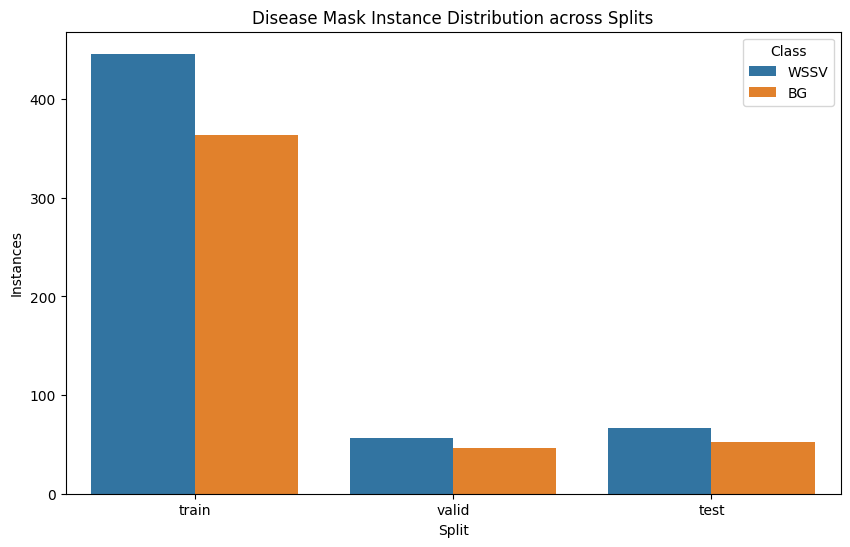

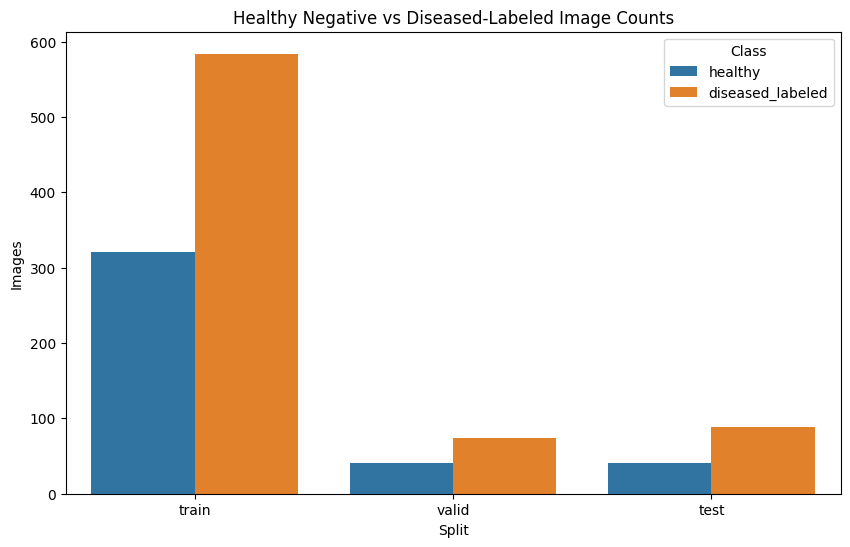

Train: 44.94% blackgill instances; 35.47% healthy negative images
Valid: 45.10% blackgill instances; 35.65% healthy negative images
Test: 43.70% blackgill instances; 31.78% healthy negative images


In [6]:
import pandas as pd
import seaborn as sns

instance_plot_data = []
image_plot_data = []
for split, split_stats in stats.items():
    image_plot_data.append({'Split': split, 'Class': HEALTHY_CLASS_NAME, 'Images': split_stats['healthy_images']})
    image_plot_data.append({'Split': split, 'Class': 'diseased_labeled', 'Images': split_stats['labeled_images']})
    for cid, count in split_stats['instance_counts'].items():
        instance_plot_data.append({'Split': split, 'Class': class_names[cid], 'Instances': count})

if instance_plot_data:
    df_instances = pd.DataFrame(instance_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_instances, x='Split', y='Instances', hue='Class')
    plt.title('Disease Mask Instance Distribution across Splits')
    plt.show()

if image_plot_data:
    df_images = pd.DataFrame(image_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_images, x='Split', y='Images', hue='Class')
    plt.title('Healthy Negative vs Diseased-Labeled Image Counts')
    plt.show()

for split, split_stats in stats.items():
    total_instances = sum(split_stats['instance_counts'].values())
    blackgill_ratio = (split_stats['instance_counts'].get(0, 0) / max(1, total_instances)) * 100
    healthy_ratio = (split_stats['healthy_images'] / max(1, split_stats['total_label_files'])) * 100
    print(f"{split.capitalize()}: {blackgill_ratio:.2f}% blackgill instances; {healthy_ratio:.2f}% healthy negative images")

## 7. Patch attention modules + AuxSegment

Cell này giữ patch attention theo notebook gốc, sau đó thêm `AuxSegment` cho Hướng 5. Ultralytics hiện tạo `sem_masks` trực tiếp từ polygon YOLO-Seg, nên không cần tạo thư mục semantic mask thủ công.

In [ ]:
from pathlib import Path
import subprocess
import sys
import py_compile
import re

ULTRA_DIR = Path("/kaggle/working/ultralytics")

if not ULTRA_DIR.exists():
    subprocess.run(["git", "clone", "https://github.com/ultralytics/ultralytics.git", str(ULTRA_DIR)], check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(ULTRA_DIR)], check=True)

conv_py = ULTRA_DIR / "ultralytics/nn/modules/conv.py"
init_py = ULTRA_DIR / "ultralytics/nn/modules/__init__.py"
tasks_py = ULTRA_DIR / "ultralytics/nn/tasks.py"

for p in [conv_py, init_py, tasks_py]:
    backup = p.with_suffix(p.suffix + ".bak_all_attention_group_run")
    if not backup.exists():
        backup.write_text(p.read_text())
        print("Backup created:", backup)

attention_code = """
# =========================================================
# Custom attention modules for YOLO11 segmentation experiments
# =========================================================

class SimAM(nn.Module):
    def __init__(self, c1=None, e_lambda=1e-4):
        super().__init__()
        self.e_lambda = e_lambda
        self.activation = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.size()
        n = h * w - 1
        if n <= 0:
            return x
        x_minus_mu_square = (x - x.mean(dim=[2, 3], keepdim=True)).pow(2)
        y = x_minus_mu_square / (
            4 * (x_minus_mu_square.sum(dim=[2, 3], keepdim=True) / n + self.e_lambda)
        ) + 0.5
        return x * self.activation(y)


class CoordAtt(nn.Module):
    def __init__(self, c1, c2=None, reduction=32):
        super().__init__()
        c2 = c1 if c2 is None else c2
        mip = max(8, c1 // reduction)
        self.conv1 = nn.Conv2d(c1, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.act = nn.SiLU()
        self.conv_h = nn.Conv2d(mip, c2, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv2d(mip, c2, kernel_size=1, stride=1, padding=0)
        self.proj = None
        if c1 != c2:
            self.proj = nn.Conv2d(c1, c2, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        identity = x
        n, c, h, w = x.size()
        x_h = x.mean(dim=3, keepdim=True)
        x_w = x.mean(dim=2, keepdim=True).permute(0, 1, 3, 2)
        y = torch.cat([x_h, x_w], dim=2)
        y = self.act(self.bn1(self.conv1(y)))
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        a_h = self.conv_h(x_h).sigmoid()
        a_w = self.conv_w(x_w).sigmoid()
        if self.proj is not None:
            identity = self.proj(identity)
        return identity * a_h * a_w


class ECAAttention(nn.Module):
    def __init__(self, c1, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y)
        y = self.sigmoid(y).transpose(-1, -2).unsqueeze(-1)
        return x * y.expand_as(x)


class CBAMAttention(nn.Module):
    def __init__(self, c1, c2=None, reduction=16, kernel_size=7):
        super().__init__()
        c2 = c1 if c2 is None else c2
        hidden = max(c1 // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(c1, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, c1, kernel_size=1, bias=False),
        )
        self.channel_sigmoid = nn.Sigmoid()
        assert kernel_size in (3, 7), "CBAM spatial kernel_size should be 3 or 7"
        padding = 3 if kernel_size == 7 else 1
        self.spatial_conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.spatial_sigmoid = nn.Sigmoid()
        self.proj = None
        if c1 != c2:
            self.proj = nn.Conv2d(c1, c2, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        ca = self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x))
        x = x * self.channel_sigmoid(ca)
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sa = torch.cat([avg_out, max_out], dim=1)
        x = x * self.spatial_sigmoid(self.spatial_conv(sa))
        if self.proj is not None:
            x = self.proj(x)
        return x


class EMAAttention(nn.Module):
    def __init__(self, c1, c2=None, groups=8):
        super().__init__()
        c2 = c1 if c2 is None else c2
        groups = max(1, int(groups))
        groups = min(groups, c1)
        if c1 % groups != 0:
            valid_groups = [g for g in [8, 4, 2, 1] if c1 % g == 0]
            groups = valid_groups[0] if valid_groups else 1
        self.c1 = c1
        self.c2 = c2
        self.groups = groups
        self.group_channels = c1 // groups
        self.softmax = nn.Softmax(dim=-1)
        self.agp = nn.AdaptiveAvgPool2d((1, 1))
        self.conv1x1 = nn.Conv2d(self.group_channels, self.group_channels, kernel_size=1, stride=1, padding=0)
        self.conv3x3 = nn.Conv2d(self.group_channels, self.group_channels, kernel_size=3, stride=1, padding=1)
        self.gn = nn.GroupNorm(self.group_channels, self.group_channels)
        self.proj = None
        if c1 != c2:
            self.proj = nn.Conv2d(c1, c2, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        b, c, h, w = x.size()
        if c != self.c1:
            return x
        if c % self.groups != 0:
            return x
        group_x = x.reshape(b * self.groups, self.group_channels, h, w)
        x_h = group_x.mean(dim=3, keepdim=True)
        x_w = group_x.mean(dim=2, keepdim=True).permute(0, 1, 3, 2)
        hw = self.conv1x1(torch.cat([x_h, x_w], dim=2))
        x_h, x_w = torch.split(hw, [h, w], dim=2)
        x1 = self.gn(group_x * x_h.sigmoid() * x_w.permute(0, 1, 3, 2).sigmoid())
        x2 = self.conv3x3(group_x)
        x11 = self.softmax(self.agp(x1).reshape(b * self.groups, self.group_channels, 1).permute(0, 2, 1))
        x12 = x2.reshape(b * self.groups, self.group_channels, h * w)
        x21 = self.softmax(self.agp(x2).reshape(b * self.groups, self.group_channels, 1).permute(0, 2, 1))
        x22 = x1.reshape(b * self.groups, self.group_channels, h * w)
        weights = (torch.matmul(x11, x12) + torch.matmul(x21, x22)).reshape(b * self.groups, 1, h, w)
        out = (group_x * weights.sigmoid()).reshape(b, c, h, w)
        if self.proj is not None:
            out = self.proj(out)
        return out
"""

# =========================================================
# Patch conv.py
# =========================================================
text = conv_py.read_text()
text = text.replace(r'\"\"\"', '"""')

if "import torch\n" not in text:
    text = text.replace("import math\n", "import math\nimport torch\n") if "import math\n" in text else "import torch\n" + text

if "import torch.nn as nn\n" not in text and "from torch import nn\n" not in text:
    text = text.replace("import torch\n", "import torch\nimport torch.nn as nn\n")

for module_name in ["SimAM", "CoordAtt", "ECAAttention", "CBAMAttention", "EMAAttention"]:
    token = f'"{module_name}",'
    if token not in text:
        if '"RepConv",\n    "SpatialAttention",' in text:
            text = text.replace(
                '    "RepConv",\n    "SpatialAttention",',
                f'    "RepConv",\n    "{module_name}",\n    "SpatialAttention",'
            )
        elif '"Concat",' in text:
            text = text.replace('"Concat",', f'"Concat",\n    "{module_name}",')

missing_any = any(
    f"class {m}(nn.Module):" not in text
    for m in ["SimAM", "CoordAtt", "ECAAttention", "CBAMAttention", "EMAAttention"]
)
if missing_any:
    text = text.rstrip() + "\n" + attention_code + "\n"

conv_py.write_text(text)
print("Patched conv.py with attention modules")

try:
    py_compile.compile(str(conv_py), doraise=True)
    print("conv.py syntax OK")
except Exception as e:
    print("conv.py syntax error:")
    print(e)
    lines = conv_py.read_text().splitlines()
    line_no = getattr(getattr(e, "exc_value", None), "lineno", 1)
    start = max(0, line_no - 8)
    end = min(len(lines), line_no + 8)
    print(f"\n--- conv.py lines {start + 1} to {end} ---")
    for i in range(start, end):
        print(f"{i + 1}: {lines[i]}")
    raise

# =========================================================
# Patch __init__.py
# =========================================================
text = init_py.read_text()

if "from .conv import (" in text:
    for module_name in ["SimAM", "CoordAtt", "ECAAttention", "CBAMAttention", "EMAAttention"]:
        conv_import_block = text.split("from .conv import (", 1)[1].split(")", 1)[0]
        if module_name not in conv_import_block:
            if "    RepConv,\n    SpatialAttention," in text:
                text = text.replace(
                    "    RepConv,\n    SpatialAttention,",
                    f"    RepConv,\n    {module_name},\n    SpatialAttention,"
                )
            elif "    Concat," in text:
                text = text.replace("    Concat,", f"    Concat,\n    {module_name},")
            else:
                text = text.replace("from .conv import (", f"from .conv import (\n    {module_name},")
else:
    for module_name in ["SimAM", "CoordAtt", "ECAAttention", "CBAMAttention", "EMAAttention"]:
        if f"from .conv import {module_name}" not in text:
            text += f"\nfrom .conv import {module_name}\n"

if "__all__" in text:
    for module_name in ["SimAM", "CoordAtt", "ECAAttention", "CBAMAttention", "EMAAttention"]:
        all_block = text.split("__all__", 1)[1]
        if f'"{module_name}"' not in all_block:
            if '"SemanticSegment",\n    "SpatialAttention",' in text:
                text = text.replace(
                    '    "SemanticSegment",\n    "SpatialAttention",',
                    f'    "SemanticSegment",\n    "{module_name}",\n    "SpatialAttention",'
                )
            elif '"Concat",' in text:
                text = text.replace('"Concat",', f'"Concat",\n    "{module_name}",')

init_py.write_text(text)
print("Patched __init__.py")

# =========================================================
# Patch tasks.py
# =========================================================
text = tasks_py.read_text()

if "from ultralytics.nn.modules import (" in text:
    for module_name in ["SimAM", "CoordAtt", "ECAAttention", "CBAMAttention", "EMAAttention"]:
        modules_import_block = text.split("from ultralytics.nn.modules import (", 1)[1].split(")", 1)[0]
        if module_name not in modules_import_block:
            if "    Segment,\n    Segment26," in text:
                text = text.replace(
                    "    Segment,\n    Segment26,",
                    f"    Segment,\n    Segment26,\n    {module_name},"
                )
            elif "    Concat," in text:
                text = text.replace("    Concat,", f"    Concat,\n    {module_name},")
            else:
                text = text.replace(
                    "from ultralytics.nn.modules import (",
                    f"from ultralytics.nn.modules import (\n    {module_name},"
                )

base_start = text.find("base_modules = frozenset")
repeat_start = text.find("repeat_modules = frozenset", base_start)
if base_start == -1 or repeat_start == -1:
    raise RuntimeError("Could not locate base_modules block in tasks.py")

def add_to_base_modules(text, module_name):
    base_start = text.find("base_modules = frozenset")
    repeat_start = text.find("repeat_modules = frozenset", base_start)
    base_block = text[base_start:repeat_start]
    if module_name in base_block:
        print(f"{module_name} already exists in base_modules")
        return text
    pattern1 = "base_modules = frozenset(\n        {"
    pattern2 = "base_modules = frozenset({"
    if pattern1 in text:
        text = text.replace(pattern1, f"base_modules = frozenset(\n        {{\n            {module_name},")
        print(f"Added {module_name} to base_modules using pattern1")
    elif pattern2 in text:
        text = text.replace(pattern2, f"base_modules = frozenset({{\n            {module_name},")
        print(f"Added {module_name} to base_modules using pattern2")
    else:
        raise RuntimeError(f"Could not insert {module_name} into base_modules.")
    return text

for module_name in ["CoordAtt", "CBAMAttention", "EMAAttention"]:
    text = add_to_base_modules(text, module_name)

# ECA and SimAM keep channel count; parse manually.
if "elif m is ECAAttention:" not in text:
    simam_anchor = """elif m is SimAM:
            c2 = ch[f]
            args = [c2, *args]"""
    eca_branch = """elif m is ECAAttention:
            c2 = ch[f]
            if len(args) >= 2:
                k_size = args[1]
            elif len(args) == 1:
                k_size = args[0]
            else:
                k_size = 3
            args = [c2, k_size]
        elif m is SimAM:
            c2 = ch[f]
            args = [c2, *args]"""
    if simam_anchor in text:
        text = text.replace(simam_anchor, eca_branch)
    else:
        detect_anchor = """elif m in frozenset(
            {
                Detect,"""
        eca_and_simam_branch = """elif m is ECAAttention:
            c2 = ch[f]
            if len(args) >= 2:
                k_size = args[1]
            elif len(args) == 1:
                k_size = args[0]
            else:
                k_size = 3
            args = [c2, k_size]
        elif m is SimAM:
            c2 = ch[f]
            args = [c2, *args]
        """
        if detect_anchor in text:
            text = text.replace(detect_anchor, eca_and_simam_branch + detect_anchor)
        else:
            raise RuntimeError("Could not find insertion point for ECAAttention/SimAM parse branch.")

if "elif m is SimAM:" not in text:
    detect_anchor = """elif m in frozenset(
            {
                Detect,"""
    simam_branch = """elif m is SimAM:
            c2 = ch[f]
            args = [c2, *args]
        """
    if detect_anchor in text:
        text = text.replace(detect_anchor, simam_branch + detect_anchor)
    else:
        raise RuntimeError("Could not find insertion point for SimAM parse branch.")

tasks_py.write_text(text)
print("Patched tasks.py")

print("Attention registration complete.")
print("IMPORTANT: Restart runtime/kernel before creating YOLO models.")


# =========================================================
# 5.5 Patch AuxSegment for Direction 5: auxiliary semantic branch
# =========================================================
head_py = ULTRA_DIR / "ultralytics" / "nn" / "modules" / "head.py"
loss_py = ULTRA_DIR / "ultralytics" / "utils" / "loss.py"
seg_train_py = ULTRA_DIR / "ultralytics" / "models" / "yolo" / "segment" / "train.py"
seg_val_py = ULTRA_DIR / "ultralytics" / "models" / "yolo" / "segment" / "val.py"

for p in [head_py, loss_py, seg_train_py, seg_val_py]:
    backup = p.with_suffix(p.suffix + ".bak_aux_semantic_direction5")
    if not backup.exists():
        backup.write_text(p.read_text())
        print("Backup created:", backup)

aux_segment_code = r"""
# =========================================================
# Auxiliary semantic segmentation branch for YOLO-Seg training
# =========================================================
class AuxSegment(Segment):
    """ + '"""' + r"""Segment head + auxiliary semantic segmentation branch.

    - During training, it returns proto as (proto, aux_logits).
    - During inference/val/predict, it behaves like the normal Segment head.
    """ + '"""' + r"""

    def __init__(self, nc=80, nm=32, npr=256, aux_c=128, aux_lambda=0.2, aux_loss_mode=0, reg_max=16, end2end=False, ch=()):
        super().__init__(nc=nc, nm=nm, npr=npr, reg_max=reg_max, end2end=end2end, ch=ch)
        self.aux_c = int(aux_c)
        self.aux_lambda = float(aux_lambda)
        # aux_loss_mode: 0 = BCE + Dice, 1 = BCE-only, 2 = Dice-only
        self.aux_loss_mode = int(aux_loss_mode)

        c_mid = max(16, int(aux_c))
        self.aux_proj = nn.ModuleList(
            nn.Sequential(
                Conv(c, c_mid, 1),
                Conv(c_mid, c_mid, 3),
            )
            for c in ch
        )
        self.aux_fuse = nn.Sequential(
            Conv(c_mid * len(ch), c_mid, 3),
            Conv(c_mid, c_mid, 3),
            nn.Conv2d(c_mid, self.nc, 1),
        )

    def forward_aux(self, x):
        target_size = x[0].shape[-2:]
        outs = []
        for feat, proj in zip(x, self.aux_proj):
            y = proj(feat)
            if y.shape[-2:] != target_size:
                y = F.interpolate(y, size=target_size, mode="bilinear", align_corners=False)
            outs.append(y)
        return self.aux_fuse(torch.cat(outs, dim=1))

    def forward(self, x):
        outputs = super().forward(x)
        if self.training:
            aux_logits = self.forward_aux(x)
            if isinstance(outputs, dict) and "proto" in outputs:
                outputs["proto"] = (outputs["proto"], aux_logits)
            return outputs
        return outputs
"""

# ---------------------------------------------------------
# Patch head.py
# ---------------------------------------------------------
text = head_py.read_text()
if "import torch.nn.functional as F" not in text:
    text = text.replace("import torch.nn as nn\n", "import torch.nn as nn\nimport torch.nn.functional as F\n")
if '"AuxSegment",' not in text and '"Segment",' in text:
    text = text.replace('"Segment",', '"Segment",\n    "AuxSegment",', 1)

# If an older AuxSegment patch exists from a previous run, replace it with the v2 version.
if "class AuxSegment(Segment):" in text and "aux_loss_mode" not in text:
    marker = "# =========================================================\n# Auxiliary semantic segmentation branch for YOLO-Seg training"
    if marker in text:
        text = text.split(marker, 1)[0].rstrip() + "\n\n" + aux_segment_code + "\n"
    else:
        raise RuntimeError("Old AuxSegment found, but could not locate replacement marker in head.py")
elif "class AuxSegment(Segment):" not in text:
    text = text.rstrip() + "\n\n" + aux_segment_code + "\n"
head_py.write_text(text)
py_compile.compile(str(head_py), doraise=True)
print("Patched head.py with AuxSegment.")

# ---------------------------------------------------------
# Patch modules/__init__.py export
# ---------------------------------------------------------
text = init_py.read_text()
if "from .head import (" in text:
    head_import_block = text.split("from .head import (", 1)[1].split(")", 1)[0]
    if "AuxSegment" not in head_import_block:
        if "    Segment,\n    Segment26," in text:
            text = text.replace("    Segment,\n    Segment26,", "    Segment,\n    AuxSegment,\n    Segment26,")
        elif "    Segment," in text:
            text = text.replace("    Segment,", "    Segment,\n    AuxSegment,")
        else:
            text = text.replace("from .head import (", "from .head import (\n    AuxSegment,")
else:
    if "from .head import AuxSegment" not in text:
        text += "\nfrom .head import AuxSegment\n"

if "__all__" in text:
    all_block = text.split("__all__", 1)[1]
    if '"AuxSegment"' not in all_block:
        if '"Segment",\n    "Segment26",' in text:
            text = text.replace('"Segment",\n    "Segment26",', '"Segment",\n    "AuxSegment",\n    "Segment26",')
        elif '"Segment",' in text:
            text = text.replace('"Segment",', '"Segment",\n    "AuxSegment",', 1)

init_py.write_text(text)
py_compile.compile(str(init_py), doraise=True)
print("Patched modules/__init__.py with AuxSegment export.")

# ---------------------------------------------------------
# Patch tasks.py parser so YAML can use AuxSegment
# ---------------------------------------------------------
text = tasks_py.read_text()

if "from ultralytics.nn.modules import (" in text:
    modules_import_block = text.split("from ultralytics.nn.modules import (", 1)[1].split(")", 1)[0]
    if "AuxSegment" not in modules_import_block:
        if "    Segment,\n    Segment26," in text:
            text = text.replace("    Segment,\n    Segment26,", "    Segment,\n    AuxSegment,\n    Segment26,")
        elif "    Segment," in text:
            text = text.replace("    Segment,", "    Segment,\n    AuxSegment,")
        else:
            text = text.replace("from ultralytics.nn.modules import (", "from ultralytics.nn.modules import (\n    AuxSegment,")

# Add AuxSegment anywhere Segment-like heads are parsed.
for old, new in [
    ("                Segment,\n                Segment26,", "                Segment,\n                AuxSegment,\n                Segment26,"),
    ("if m is Segment or m is YOLOESegment or m is Segment26 or m is YOLOESegment26:",
     "if m is Segment or m is AuxSegment or m is YOLOESegment or m is Segment26 or m is YOLOESegment26:"),
    ("{Detect, YOLOEDetect, Segment, Segment26, YOLOESegment, YOLOESegment26, Pose, Pose26, OBB, OBB26}",
     "{Detect, YOLOEDetect, Segment, AuxSegment, Segment26, YOLOESegment, YOLOESegment26, Pose, Pose26, OBB, OBB26}"),
]:
    if old in text and new not in text:
        text = text.replace(old, new)

tasks_py.write_text(text)
py_compile.compile(str(tasks_py), doraise=True)
print("Patched tasks.py with AuxSegment parsing.")

# ---------------------------------------------------------
# Patch loss.py aux weight. Latest Ultralytics already creates sem_masks from YOLO-Seg polygons.
# ---------------------------------------------------------
text = loss_py.read_text()
if "pred_semantic" not in text or "sem_masks" not in text:
    raise RuntimeError(
        "This Ultralytics loss.py does not expose semantic auxiliary segmentation support "
        "(pred_semantic/sem_masks not found). Use a newer Ultralytics version."
    )

# Insert auxiliary semantic loss controls.
anchor = "self.bcedice_loss = BCEDiceLoss(weight_bce=0.5, weight_dice=0.5)"
aux_init_block = (
    "self.bcedice_loss = BCEDiceLoss(weight_bce=0.5, weight_dice=0.5)\n"
    "        self.aux_lambda = float(getattr(model.model[-1], \"aux_lambda\", 0.2))\n"
    "        self.aux_loss_mode = int(getattr(model.model[-1], \"aux_loss_mode\", 0))\n"
    "        self.bce_sem_loss = BCEDiceLoss(weight_bce=1.0, weight_dice=0.0)\n"
    "        self.dice_sem_loss = BCEDiceLoss(weight_bce=0.0, weight_dice=1.0)"
)

if "self.aux_loss_mode" not in text:
    if anchor in text:
        text = text.replace(anchor, aux_init_block)
    elif "self.aux_lambda" in text:
        text = text.replace(
            "self.aux_lambda = float(getattr(model.model[-1], \"aux_lambda\", 0.2))",
            "self.aux_lambda = float(getattr(model.model[-1], \"aux_lambda\", 0.2))\n"
            "        self.aux_loss_mode = int(getattr(model.model[-1], \"aux_loss_mode\", 0))\n"
            "        self.bce_sem_loss = BCEDiceLoss(weight_bce=1.0, weight_dice=0.0)\n"
            "        self.dice_sem_loss = BCEDiceLoss(weight_bce=0.0, weight_dice=1.0)"
        )
    else:
        raise RuntimeError("Could not insert aux loss controls into v8SegmentationLoss.__init__")

def build_aux_loss_block(indent):
    body = indent + "    "
    return "\n".join(
        [
            f"{indent}if self.aux_loss_mode == 1:",
            f"{body}loss[4] = self.aux_lambda * self.bce_sem_loss(pred_semantic, sem_masks)",
            f"{indent}elif self.aux_loss_mode == 2:",
            f"{body}loss[4] = self.aux_lambda * self.dice_sem_loss(pred_semantic, sem_masks)",
            f"{indent}else:",
            f"{body}loss[4] = self.aux_lambda * self.bcedice_loss(pred_semantic, sem_masks)",
        ]
    )

# Normalize either a previous aux_loss_mode patch, the lambda-only patch, or the original Ultralytics line.
# This also repairs loss.py if a previous notebook run wrote the malformed block before py_compile failed.
aux_block_pattern = re.compile(
    r"^(?P<indent>[ \t]*)if self\.aux_loss_mode == 1:\n"
    r"^[ \t]*loss\[4\] = self\.aux_lambda \* self\.bce_sem_loss\(pred_semantic, sem_masks\)\n"
    r"^[ \t]*elif self\.aux_loss_mode == 2:\n"
    r"^[ \t]*loss\[4\] = self\.aux_lambda \* self\.dice_sem_loss\(pred_semantic, sem_masks\)\n"
    r"^[ \t]*else:\n"
    r"^[ \t]*loss\[4\] = self\.aux_lambda \* self\.bcedice_loss\(pred_semantic, sem_masks\)",
    flags=re.MULTILINE,
)
match = aux_block_pattern.search(text)
if match:
    text = text[: match.start()] + build_aux_loss_block(match.group("indent")) + text[match.end() :]
else:
    replacement_patterns = [
        r"^(?P<indent>[ \t]*)loss\[4\] = self\.aux_lambda \* self\.bcedice_loss\(pred_semantic, sem_masks\)$",
        r"^(?P<indent>[ \t]*)loss\[4\] = self\.bcedice_loss\(pred_semantic, sem_masks\)$",
    ]
    for pattern in replacement_patterns:
        match = re.search(pattern, text, flags=re.MULTILINE)
        if match:
            text = text[: match.start()] + build_aux_loss_block(match.group("indent")) + text[match.end() :]
            break
    else:
        raise RuntimeError("Could not replace semantic auxiliary loss assignment in loss.py")

loss_py.write_text(text)
py_compile.compile(str(loss_py), doraise=True)
print("Patched loss.py with aux_lambda and aux_loss_mode controls.")

# ---------------------------------------------------------
# Patch segmentation trainer loss names if needed.
# ---------------------------------------------------------
text = seg_train_py.read_text()
if '"sem_loss"' not in text:
    text = text.replace(
        'self.loss_names = "box_loss", "seg_loss", "cls_loss", "dfl_loss"',
        'self.loss_names = "box_loss", "seg_loss", "cls_loss", "dfl_loss", "sem_loss"'
    )
seg_train_py.write_text(text)
py_compile.compile(str(seg_train_py), doraise=True)
print("Patched segmentation trainer loss_names.")


# ---------------------------------------------------------
# Patch segmentation validator mask-IoU shape alignment.
# ---------------------------------------------------------
# P2/P3/P4 AuxSegment intentionally uses a higher-resolution prototype source than
# the standard P3/P4/P5 Segment head. This may make predicted validation masks have
# a different HxW from GT masks when mask_ratio remains at the default value.
# Keep the ablation configuration unchanged and align only tensors used for IoU.
text = seg_val_py.read_text()
if "import torch.nn.functional as F" not in text:
    if "import torch" in text:
        text = text.replace("import torch", "import torch.nn.functional as F", 1)
    else:
        text = "import torch.nn.functional as F" + text

old_iou_line = '            iou = mask_iou(batch["masks"].flatten(1), preds["masks"].flatten(1).float())  # float, uint8'
new_iou_block = '            gt_masks = batch["masks"]\n            pred_masks = preds["masks"].float()\n            if gt_masks.ndim == 2:\n                gt_side = int(gt_masks.shape[1] ** 0.5)\n                gt_masks = gt_masks.reshape(gt_masks.shape[0], gt_side, gt_side)\n            if pred_masks.ndim == 2:\n                pred_side = int(pred_masks.shape[1] ** 0.5)\n                pred_masks = pred_masks.reshape(pred_masks.shape[0], pred_side, pred_side)\n            if gt_masks.shape[-2:] != pred_masks.shape[-2:]:\n                pred_masks = F.interpolate(\n                    pred_masks[:, None], size=gt_masks.shape[-2:], mode="bilinear", align_corners=False\n                )[:, 0]\n            iou = mask_iou(gt_masks.flatten(1), pred_masks.flatten(1).float())  # float, uint8'
if 'gt_masks = batch["masks"]' not in text:
    if old_iou_line not in text:
        raise RuntimeError("Could not find segment validator mask_iou line to patch")
    text = text.replace(old_iou_line, new_iou_block, 1)
seg_val_py.write_text(text)
py_compile.compile(str(seg_val_py), doraise=True)
print("Patched segmentation validator mask-IoU shape alignment.")

import importlib, sys
# Evict all cached ultralytics submodules so patched .py files are reloaded.
# importlib.invalidate_caches() only clears the finder cache, not sys.modules.
_to_del = [k for k in sys.modules if "ultralytics" in k]
for _k in _to_del:
    del sys.modules[_k]
importlib.invalidate_caches()
print(f"Evicted {len(_to_del)} ultralytics modules from sys.modules.")
print("\nPatch complete: attention modules + AuxSegment are ready.")


Cloning into '/kaggle/working/ultralytics'...


Backup created: /kaggle/working/ultralytics/ultralytics/nn/modules/conv.py.bak_all_attention_group_run
Backup created: /kaggle/working/ultralytics/ultralytics/nn/modules/__init__.py.bak_all_attention_group_run
Backup created: /kaggle/working/ultralytics/ultralytics/nn/tasks.py.bak_all_attention_group_run
Patched conv.py with attention modules
conv.py syntax OK
Patched __init__.py
Added CoordAtt to base_modules using pattern1
Added CBAMAttention to base_modules using pattern1
Added EMAAttention to base_modules using pattern1
Patched tasks.py
Attention registration complete.
IMPORTANT: Restart runtime/kernel before creating YOLO models.
Backup created: /kaggle/working/ultralytics/ultralytics/nn/modules/head.py.bak_aux_semantic_direction5
Backup created: /kaggle/working/ultralytics/ultralytics/utils/loss.py.bak_aux_semantic_direction5
Backup created: /kaggle/working/ultralytics/ultralytics/models/yolo/segment/train.py.bak_aux_semantic_direction5
Patched head.py with AuxSegment.
Patched mo

## 8. Create YAML files

Giữ toàn bộ YAML attention như notebook gốc và thêm YAML cho `SimAM_CA + AuxSegment` với `aux_lambda=0.2`.

In [8]:
from pathlib import Path

ULTRA_DIR = Path("/kaggle/working/ultralytics")
MODEL_CFG_DIR = ULTRA_DIR / "ultralytics/cfg/models/11"
MODEL_CFG_DIR.mkdir(parents=True, exist_ok=True)

# aux_loss_mode:
#   0 = BCE + Dice semantic loss
#   1 = BCE-only semantic loss
#   2 = Dice-only semantic loss

BASE_YAML_TEMPLATE = """nc: 2
scales:
  n: [0.50, 0.25, 1024]
  s: [0.50, 0.50, 1024]
  m: [0.50, 1.00, 512]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.50, 512]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 2, C3k2, [256, False, 0.25]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 2, C3k2, [512, False, 0.25]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 2, C3k2, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 2, C3k2, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]
  - [-1, 2, C2PSA, [1024]]

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]

  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 2, C3k2, [256, False]]

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 13], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 10], 1, Concat, [1]]
  - [-1, 2, C3k2, [1024, True]]

{attention_layers}
"""

P2_YAML_TEMPLATE = """nc: 2
scales:
  n: [0.50, 0.25, 1024]
  s: [0.50, 0.50, 1024]
  m: [0.50, 1.00, 512]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.50, 512]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 2, C3k2, [256, False, 0.25]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 2, C3k2, [512, False, 0.25]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 2, C3k2, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 2, C3k2, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]
  - [-1, 2, C2PSA, [1024]]

head:
  # P5 -> P4
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]

  # P4 -> P3
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 2, C3k2, [256, False]]

  # P3 -> P2 high-resolution branch
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 2], 1, Concat, [1]]
  - [-1, 2, C3k2, [128, False]]

  # P2 -> P3
  - [-1, 1, Conv, [128, 3, 2]]
  - [[-1, 16], 1, Concat, [1]]
  - [-1, 2, C3k2, [256, False]]

  # P3 -> P4
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 13], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]

  # P4 -> P5, retained in model but not used by P2/P3/P4 AuxSegment variants below
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 10], 1, Concat, [1]]
  - [-1, 2, C3k2, [1024, True]]

{attention_layers}
"""

YAML_LAYER_DEFS = {
    # Baseline attention, no auxiliary branch.
    "simam_ca": (BASE_YAML_TEMPLATE, "yolo11n-seg-simam-ca-head.yaml", """  # CA -> SimAM before Segment head.
  - [16, 1, CoordAtt, [256, 32]]
  - [23, 1, SimAM, []]

  - [19, 1, CoordAtt, [512, 32]]
  - [25, 1, SimAM, []]

  - [22, 1, CoordAtt, [1024, 32]]
  - [27, 1, SimAM, []]

  - [[24, 26, 28], 1, Segment, [nc, 32, 256]]"""),

    # P3/P4/P5 AuxSegment ablations.
    "simam_ca_aux_l005": (BASE_YAML_TEMPLATE, "yolo11n-seg-simam-ca-aux-l005-head.yaml", """  # CA -> SimAM + AuxSegment lambda=0.05, BCE+Dice.
  - [16, 1, CoordAtt, [256, 32]]
  - [23, 1, SimAM, []]

  - [19, 1, CoordAtt, [512, 32]]
  - [25, 1, SimAM, []]

  - [22, 1, CoordAtt, [1024, 32]]
  - [27, 1, SimAM, []]

  - [[24, 26, 28], 1, AuxSegment, [nc, 32, 256, 128, 0.05, 0]]"""),

    "simam_ca_aux_l01": (BASE_YAML_TEMPLATE, "yolo11n-seg-simam-ca-aux-l01-head.yaml", """  # CA -> SimAM + AuxSegment lambda=0.1, BCE+Dice.
  - [16, 1, CoordAtt, [256, 32]]
  - [23, 1, SimAM, []]

  - [19, 1, CoordAtt, [512, 32]]
  - [25, 1, SimAM, []]

  - [22, 1, CoordAtt, [1024, 32]]
  - [27, 1, SimAM, []]

  - [[24, 26, 28], 1, AuxSegment, [nc, 32, 256, 128, 0.1, 0]]"""),

    "simam_ca_aux_l01_bce": (BASE_YAML_TEMPLATE, "yolo11n-seg-simam-ca-aux-l01-bce-head.yaml", """  # CA -> SimAM + AuxSegment lambda=0.1, BCE-only semantic loss.
  - [16, 1, CoordAtt, [256, 32]]
  - [23, 1, SimAM, []]

  - [19, 1, CoordAtt, [512, 32]]
  - [25, 1, SimAM, []]

  - [22, 1, CoordAtt, [1024, 32]]
  - [27, 1, SimAM, []]

  - [[24, 26, 28], 1, AuxSegment, [nc, 32, 256, 128, 0.1, 1]]"""),

    # P2/P3/P4 high-resolution AuxSegment variants.
    "simam_ca_p2_aux_l01": (P2_YAML_TEMPLATE, "yolo11n-seg-simam-ca-p2p3p4-aux-l01-head.yaml", """  # P2/P3/P4 CA -> SimAM + AuxSegment lambda=0.1, BCE+Dice.
  - [19, 1, CoordAtt, [128, 32]]
  - [29, 1, SimAM, []]

  - [22, 1, CoordAtt, [256, 32]]
  - [31, 1, SimAM, []]

  - [25, 1, CoordAtt, [512, 32]]
  - [33, 1, SimAM, []]

  - [[30, 32, 34], 1, AuxSegment, [nc, 32, 256, 128, 0.1, 0]]"""),

    "simam_ca_p2_aux_l005": (P2_YAML_TEMPLATE, "yolo11n-seg-simam-ca-p2p3p4-aux-l005-head.yaml", """  # P2/P3/P4 CA -> SimAM + AuxSegment lambda=0.05, BCE+Dice.
  - [19, 1, CoordAtt, [128, 32]]
  - [29, 1, SimAM, []]

  - [22, 1, CoordAtt, [256, 32]]
  - [31, 1, SimAM, []]

  - [25, 1, CoordAtt, [512, 32]]
  - [33, 1, SimAM, []]

  - [[30, 32, 34], 1, AuxSegment, [nc, 32, 256, 128, 0.05, 0]]"""),

    "simam_ca_p2_aux_l01_bce": (P2_YAML_TEMPLATE, "yolo11n-seg-simam-ca-p2p3p4-aux-l01-bce-head.yaml", """  # P2/P3/P4 CA -> SimAM + AuxSegment lambda=0.1, BCE-only semantic loss.
  - [19, 1, CoordAtt, [128, 32]]
  - [29, 1, SimAM, []]

  - [22, 1, CoordAtt, [256, 32]]
  - [31, 1, SimAM, []]

  - [25, 1, CoordAtt, [512, 32]]
  - [33, 1, SimAM, []]

  - [[30, 32, 34], 1, AuxSegment, [nc, 32, 256, 128, 0.1, 1]]"""),
}

MODEL_YAML_PATHS = {}
for key, (template, yaml_name, layers) in YAML_LAYER_DEFS.items():
    yaml_text = template.format(attention_layers=layers)
    yaml_path = MODEL_CFG_DIR / yaml_name
    yaml_path.write_text(yaml_text)
    MODEL_YAML_PATHS[key] = str(yaml_path)
    print("Created:", key, "->", yaml_path)


Created: simam_ca -> /kaggle/working/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-simam-ca-head.yaml
Created: simam_ca_aux_l005 -> /kaggle/working/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-simam-ca-aux-l005-head.yaml
Created: simam_ca_aux_l01 -> /kaggle/working/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-simam-ca-aux-l01-head.yaml
Created: simam_ca_aux_l01_bce -> /kaggle/working/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-simam-ca-aux-l01-bce-head.yaml
Created: simam_ca_p2_aux_l01 -> /kaggle/working/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-simam-ca-p2p3p4-aux-l01-head.yaml
Created: simam_ca_p2_aux_l005 -> /kaggle/working/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-simam-ca-p2p3p4-aux-l005-head.yaml
Created: simam_ca_p2_aux_l01_bce -> /kaggle/working/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-simam-ca-p2p3p4-aux-l01-bce-head.yaml


## 9. Smoke test YAML + AuxSegment

In [9]:
import sys
import torch
from pathlib import Path

sys.path.insert(0, "/kaggle/working/ultralytics")
from ultralytics import YOLO

# Smoke test để chắc chắn YAML + AuxSegment parse được.
SMOKE_TEST_KEYS = [
    "simam_ca",
    "simam_ca_aux_l005",
    "simam_ca_aux_l01",
    "simam_ca_aux_l01_bce",
    "simam_ca_p2_aux_l01",
]

for key in SMOKE_TEST_KEYS:
    print("\nTesting:", key)
    model = YOLO(MODEL_YAML_PATHS[key])
    model.model.train()
    with torch.no_grad():
        preds = model.model(torch.zeros(1, 3, 640, 640))
    print("training output type:", type(preds))
    if "aux" in key:
        assert isinstance(preds, dict), "AuxSegment training output should be dict"
        assert isinstance(preds.get("proto"), tuple), "AuxSegment should return proto tuple: (proto, aux_logits)"
        proto, aux_logits = preds["proto"]
        print("proto:", tuple(proto.shape), "aux_logits:", tuple(aux_logits.shape))
        if "p2" in key:
            assert aux_logits.shape[-1] == 160, "P2/P3/P4 aux logits should be 160x160 at imgsz=640"
        else:
            assert aux_logits.shape[-1] == 80, "P3/P4/P5 aux logits should be 80x80 at imgsz=640"
    else:
        print("proto:", tuple(preds["proto"].shape) if isinstance(preds, dict) and "proto" in preds else "N/A")

print("\nSmoke test passed.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Testing: simam_ca
training output type: <class 'dict'>
proto: (1, 32, 160, 160)

Testing: simam_ca_aux_l005
training output type: <class 'dict'>
proto: (1, 32, 160, 160) aux_logits: (1, 2, 80, 80)

Testing: simam_ca_aux_l01
training output type: <class 'dict'>
proto: (1, 32, 160, 160) aux_logits: (1, 2, 80, 80)

Testing: simam_ca_aux_l01_bce
training output type: <class 'dict'>
proto: (1, 32, 160, 160) aux_logits: (1, 2, 80, 80)

Testing: simam_ca_p2_aux_l01
training output type: <class 'dict'>
proto: (1, 32, 320, 320) aux_logits: (1, 2, 160, 160)

Smoke test passed.


## 10. Preview semantic mask sinh từ polygon YOLO-Seg

Đây là kiểm tra trực quan phụ. Khi train, Ultralytics sẽ tự tạo `sem_masks` từ polygon instance.

has_label num_polygons bg_pixels wssv_pixels lesion_pixel_ratio  \
            sum          sum       sum         sum               mean   
split                                                                   
test         88          119   1748358     2607609           0.008051   
train       584          810  11931594    15597862           0.007253   
valid        74          102   1602569     2187048           0.007857   

                           
         median       max  
split                      
test   0.007609  0.030823  
train  0.006720  0.039665  
valid  0.007046  0.045779

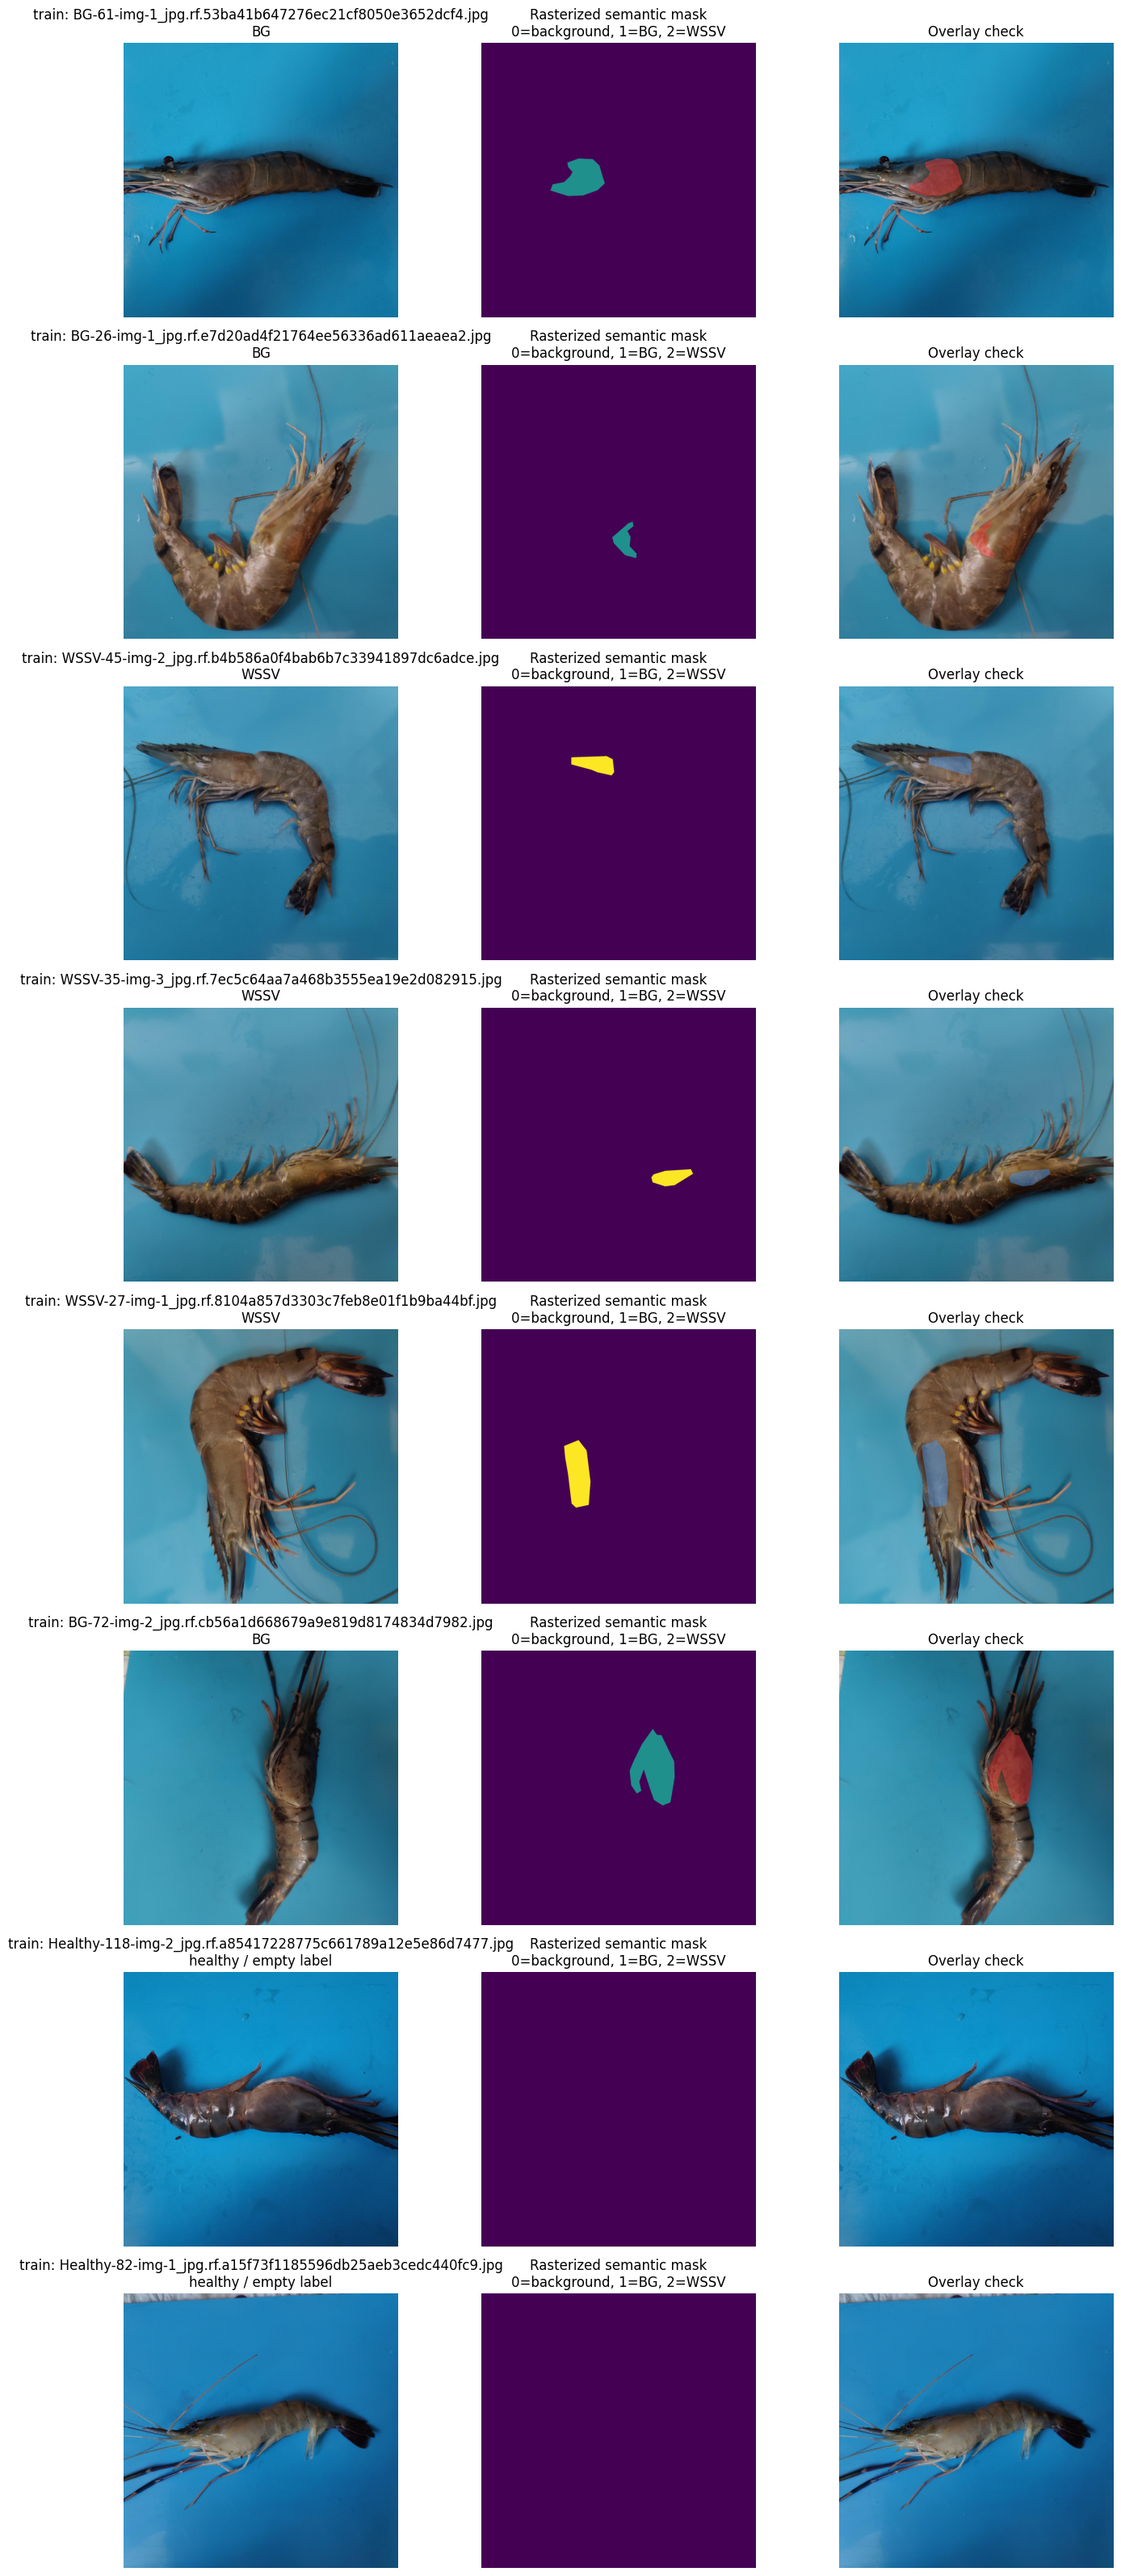

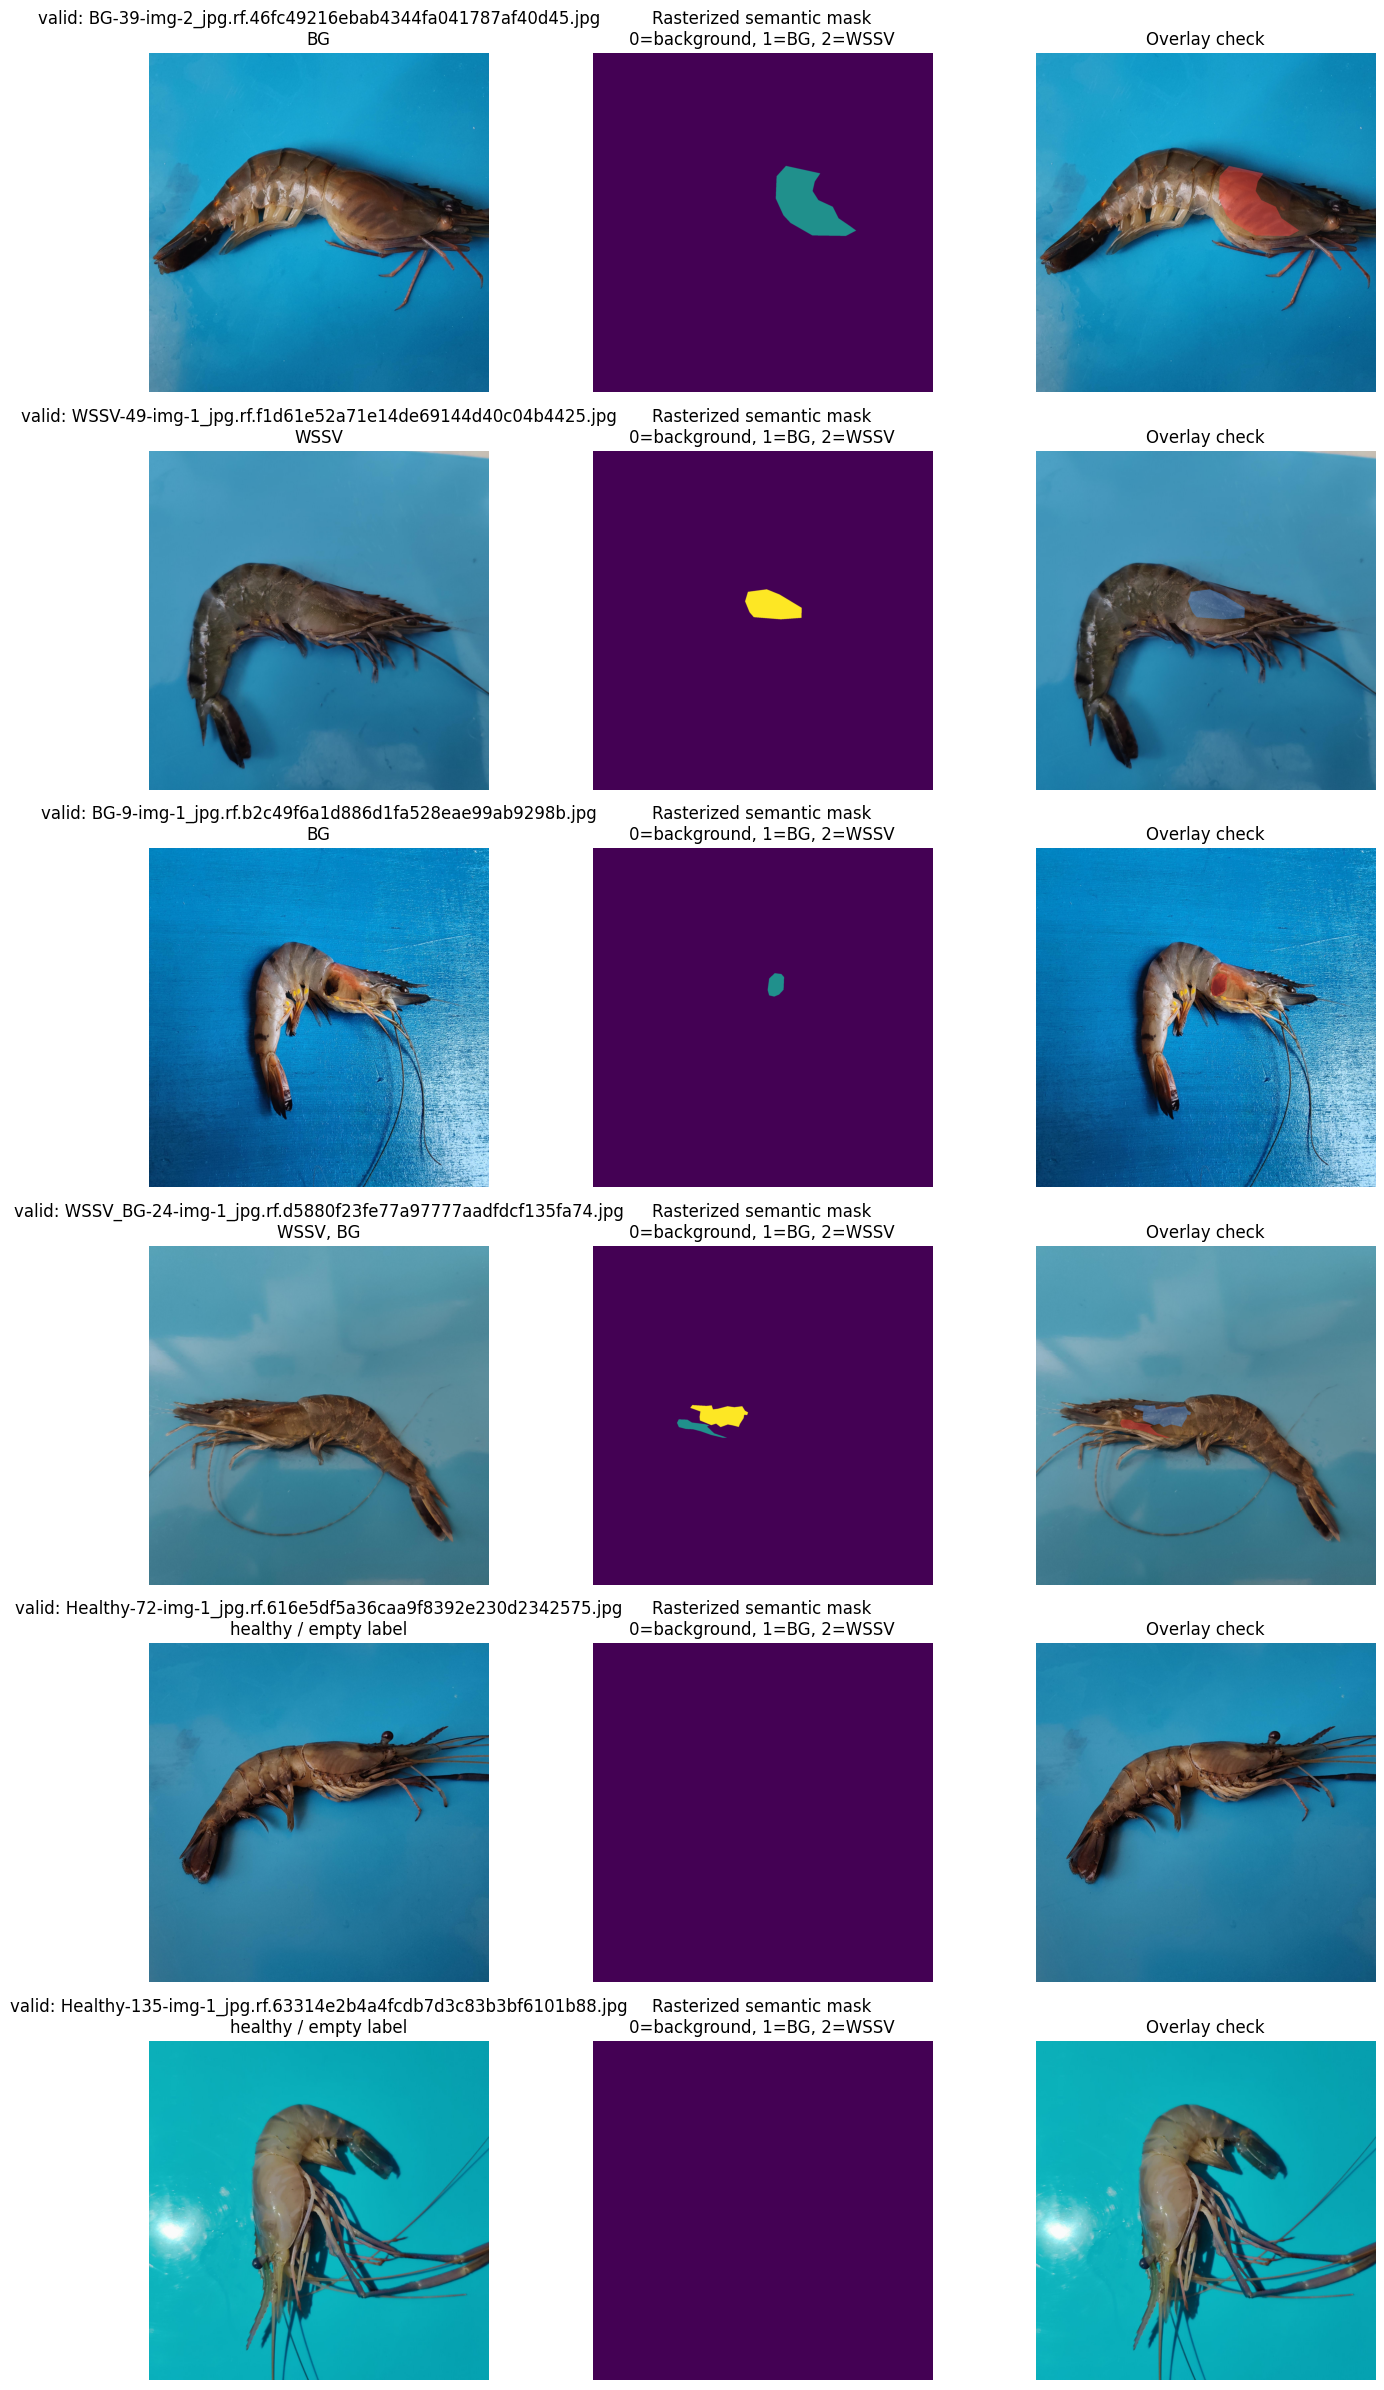

In [10]:
import random
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

SEMANTIC_COLORS = {
    0: np.array([0, 0, 0], dtype=np.uint8),       # background
    1: np.array([255, 70, 70], dtype=np.uint8),   # BG visual id = class 0 + 1
    2: np.array([70, 160, 255], dtype=np.uint8),  # WSSV visual id = class 1 + 1
}

CLASS_ID_TO_NAME = {0: "BG", 1: "WSSV"}


def find_images(split="train"):
    image_dir = Path(base_path) / split / "images"
    images = []
    for ext in IMAGE_EXTENSIONS:
        images.extend(image_dir.glob(f"*{ext}"))
    return sorted(images)


def rasterize_yolo_seg_label(image_path, label_path):
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(image_path)
    h, w = img.shape[:2]
    sem = np.zeros((h, w), dtype=np.uint8)
    polygons = []
    if not Path(label_path).exists():
        return sem, polygons
    for line in Path(label_path).read_text().splitlines():
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        cls = int(float(parts[0]))
        coords = np.array([float(x) for x in parts[1:]], dtype=np.float32).reshape(-1, 2)
        pts = np.stack([coords[:, 0] * w, coords[:, 1] * h], axis=1).round().astype(np.int32)
        # +1 chỉ để visualize background rõ ràng. Training vẫn dùng class id gốc trong loss của Ultralytics.
        cv2.fillPoly(sem, [pts], cls + 1)
        polygons.append({"class_id": cls, "class_name": CLASS_ID_TO_NAME.get(cls, str(cls)), "points": len(pts)})
    return sem, polygons


def overlay_semantic_mask(img_rgb, sem, alpha=0.45):
    overlay = img_rgb.copy()
    color_mask = np.zeros_like(img_rgb, dtype=np.uint8)
    for k, color in SEMANTIC_COLORS.items():
        color_mask[sem == k] = color
    mask = sem > 0
    overlay[mask] = ((1 - alpha) * overlay[mask] + alpha * color_mask[mask]).astype(np.uint8)
    return overlay


def semantic_mask_statistics(split="train"):
    rows = []
    for img in find_images(split):
        label = Path(base_path) / split / "labels" / f"{img.stem}.txt"
        sem, polygons = rasterize_yolo_seg_label(img, label)
        total_px = sem.size
        rows.append({
            "split": split,
            "image": img.name,
            "has_label": bool(polygons),
            "num_polygons": len(polygons),
            "bg_pixels": int((sem == 1).sum()),
            "wssv_pixels": int((sem == 2).sum()),
            "lesion_pixel_ratio": float((sem > 0).sum() / max(1, total_px)),
        })
    return pd.DataFrame(rows)


def show_semantic_preview(split="train", n_labeled=6, n_healthy=2, seed=42):
    rng = random.Random(seed)
    imgs = find_images(split)
    labeled, healthy = [], []
    for img in imgs:
        label = Path(base_path) / split / "labels" / f"{img.stem}.txt"
        if label.exists() and label.read_text().strip():
            labeled.append(img)
        else:
            healthy.append(img)
    sample = rng.sample(labeled, min(n_labeled, len(labeled))) + rng.sample(healthy, min(n_healthy, len(healthy)))
    if not sample:
        print("No images found.")
        return
    plt.figure(figsize=(14, 4 * len(sample)))
    for i, img_path in enumerate(sample):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        label_path = Path(base_path) / split / "labels" / f"{img_path.stem}.txt"
        sem, polygons = rasterize_yolo_seg_label(img_path, label_path)
        overlay = overlay_semantic_mask(img, sem)
        cls_info = ", ".join([p["class_name"] for p in polygons]) if polygons else "healthy / empty label"

        plt.subplot(len(sample), 3, 3 * i + 1)
        plt.imshow(img)
        plt.title(f"{split}: {img_path.name}\n{cls_info}")
        plt.axis("off")

        plt.subplot(len(sample), 3, 3 * i + 2)
        plt.imshow(sem, vmin=0, vmax=2)
        plt.title("Rasterized semantic mask\n0=background, 1=BG, 2=WSSV")
        plt.axis("off")

        plt.subplot(len(sample), 3, 3 * i + 3)
        plt.imshow(overlay)
        plt.title("Overlay check")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Thống kê nhanh để phát hiện mask rỗng/sai tỷ lệ.
all_sem_stats = pd.concat([semantic_mask_statistics(s) for s in ["train", "valid", "test"]], ignore_index=True)
display(all_sem_stats.groupby("split")[["has_label", "num_polygons", "bg_pixels", "wssv_pixels", "lesion_pixel_ratio"]].agg({
    "has_label": "sum",
    "num_polygons": "sum",
    "bg_pixels": "sum",
    "wssv_pixels": "sum",
    "lesion_pixel_ratio": ["mean", "median", "max"],
}))

show_semantic_preview("train", n_labeled=6, n_healthy=2, seed=42)
show_semantic_preview("valid", n_labeled=4, n_healthy=2, seed=43)


## 11. Select experiment group cho ablation Hướng 5

Mặc định notebook chạy các cấu hình chính để so sánh với A0. Nếu cần chạy nhanh, sửa `RUN_ONLY_KEYS` trong cell dưới để chọn ít experiment hơn.


In [11]:
from pathlib import Path
import sys

sys.path.insert(0, "/kaggle/working/ultralytics")

EXPERIMENT_ROOT_STR = "/kaggle/working/yolo11n_aux_semantic_direction5_ablation_v2"
RUN_BASE_NAME = "yolo11n_seg_simam_ca_aux_direction5_ablation_v2"

# loss_mode ghi chú:
#   bce_dice = BCE + Dice semantic auxiliary loss
#   bce_only = chỉ BCE semantic loss, dùng để kiểm tra khi Dice gây nhiễu
ALL_EXPERIMENTS = [
    {
        "key": "a0_simam_ca",
        "name": "A0 - SimAM_CA, no auxiliary branch",
        "model_type": "attention_baseline",
        "yaml": MODEL_YAML_PATHS["simam_ca"],
        "aux_lambda": 0.0,
        "aux_feature_set": "none",
        "aux_loss_mode_name": "none",
        "train_args": {},
    },
    {
        "key": "a1_aux_l005",
        "name": "A1 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.05, BCE+Dice",
        "model_type": "aux_attention",
        "yaml": MODEL_YAML_PATHS["simam_ca_aux_l005"],
        "aux_lambda": 0.05,
        "aux_feature_set": "P3/P4/P5",
        "aux_loss_mode_name": "bce_dice",
        "train_args": {},
    },
    {
        "key": "a2_aux_l01",
        "name": "A2 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1, BCE+Dice",
        "model_type": "aux_attention",
        "yaml": MODEL_YAML_PATHS["simam_ca_aux_l01"],
        "aux_lambda": 0.1,
        "aux_feature_set": "P3/P4/P5",
        "aux_loss_mode_name": "bce_dice",
        "train_args": {},
    },
    {
        "key": "a3_aux_l01_maskr2",
        "name": "A3 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1 + mask_ratio=2",
        "model_type": "aux_attention",
        "yaml": MODEL_YAML_PATHS["simam_ca_aux_l01"],
        "aux_lambda": 0.1,
        "aux_feature_set": "P3/P4/P5",
        "aux_loss_mode_name": "bce_dice",
        "train_args": {"mask_ratio": 2},
    },
    {
        "key": "a4_aux_l01_bce",
        "name": "A4 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1, BCE-only semantic loss",
        "model_type": "aux_attention_bce_only",
        "yaml": MODEL_YAML_PATHS["simam_ca_aux_l01_bce"],
        "aux_lambda": 0.1,
        "aux_feature_set": "P3/P4/P5",
        "aux_loss_mode_name": "bce_only",
        "train_args": {},
    },
    {
        "key": "a5_p2_aux_l01",
        "name": "A5 - SimAM_CA + P2/P3/P4 AuxSegment lambda=0.1, BCE+Dice",
        "model_type": "p2_aux_attention",
        "yaml": MODEL_YAML_PATHS["simam_ca_p2_aux_l01"],
        "aux_lambda": 0.1,
        "aux_feature_set": "P2/P3/P4",
        "aux_loss_mode_name": "bce_dice",
        "train_args": {},
    },
    {
        "key": "a6_p2_aux_l01_maskr2",
        "name": "A6 - SimAM_CA + P2/P3/P4 AuxSegment lambda=0.1 + mask_ratio=2",
        "model_type": "p2_aux_attention",
        "yaml": MODEL_YAML_PATHS["simam_ca_p2_aux_l01"],
        "aux_lambda": 0.1,
        "aux_feature_set": "P2/P3/P4",
        "aux_loss_mode_name": "bce_dice",
        "train_args": {"mask_ratio": 2},
    },
    {
        "key": "a7_p2_aux_l01_bce",
        "name": "A7 - SimAM_CA + P2/P3/P4 AuxSegment lambda=0.1, BCE-only semantic loss",
        "model_type": "p2_aux_attention_bce_only",
        "yaml": MODEL_YAML_PATHS["simam_ca_p2_aux_l01_bce"],
        "aux_lambda": 0.1,
        "aux_feature_set": "P2/P3/P4",
        "aux_loss_mode_name": "bce_only",
        "train_args": {},
    },
]

# Để chạy nhanh, có thể sửa thành ví dụ:
# RUN_ONLY_KEYS = ["a0_simam_ca", "a1_aux_l005", "a2_aux_l01"]
RUN_ONLY_KEYS = [e["key"] for e in ALL_EXPERIMENTS]
EXPERIMENTS = [e for e in ALL_EXPERIMENTS if e["key"] in RUN_ONLY_KEYS]

print("Direction 5 ablation experiments:")
for e in EXPERIMENTS:
    print("-", e["key"], ":", e["name"], "| train_args=", e.get("train_args", {}))


Direction 5 ablation experiments:
- a0_simam_ca : A0 - SimAM_CA, no auxiliary branch | train_args= {}
- a1_aux_l005 : A1 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.05, BCE+Dice | train_args= {}
- a2_aux_l01 : A2 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1, BCE+Dice | train_args= {}
- a3_aux_l01_maskr2 : A3 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1 + mask_ratio=2 | train_args= {'mask_ratio': 2}
- a4_aux_l01_bce : A4 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1, BCE-only semantic loss | train_args= {}
- a5_p2_aux_l01 : A5 - SimAM_CA + P2/P3/P4 AuxSegment lambda=0.1, BCE+Dice | train_args= {}
- a6_p2_aux_l01_maskr2 : A6 - SimAM_CA + P2/P3/P4 AuxSegment lambda=0.1 + mask_ratio=2 | train_args= {'mask_ratio': 2}
- a7_p2_aux_l01_bce : A7 - SimAM_CA + P2/P3/P4 AuxSegment lambda=0.1, BCE-only semantic loss | train_args= {}


## 12. Train và đánh giá theo đúng thông số notebook gốc mới

In [12]:
import csv
import gc
import math
import os
import random
import shutil
import time
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from ultralytics import YOLO

# =========================================================
# Ultralytics optional integration callback fix
# =========================================================
# Some Kaggle/Colab environments can have a mismatched Ultralytics install
# where optional integrations are missing. These integrations are not needed here.
try:
    import ultralytics.utils.callbacks.base as yolo_callbacks_base

    def _disable_optional_integration_callbacks(instance):
        return None

    yolo_callbacks_base.add_integration_callbacks = _disable_optional_integration_callbacks
    print("Disabled optional Ultralytics integration callbacks: hub/wandb/mlflow/etc.")
except Exception as e:
    print("Warning: could not patch Ultralytics integration callbacks:", e)

# Prefer local cloned Ultralytics if it exists.
try:
    import sys
    local_ultra = Path("/kaggle/working/ultralytics")
    if local_ultra.exists() and str(local_ultra) not in sys.path:
        sys.path.insert(0, str(local_ultra))
        print("Inserted local Ultralytics path:", local_ultra)
except Exception as e:
    print("Warning: could not insert local Ultralytics path:", e)


# =========================================================
# Reproducibility
# =========================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Match original baseline-matched notebook: fixed seed, but do not force deterministic CUDA algorithms.
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
try:
    torch.use_deterministic_algorithms(False)
except Exception as e:
    print("Could not reset deterministic algorithms:", e)

# =========================================================
# Paths and clean augmentation
# =========================================================
# =========================================================
# Training parameters copied from yolo11n_combined_attention_modules_group_run_match_baseline.ipynb
# =========================================================
TRAIN_IMGSZ = 640
TRAIN_EPOCHS = 100
TRAIN_BATCH = 16
TRAIN_PATIENCE = 30
TRAIN_SEED = 42

EXPERIMENT_ROOT = Path(EXPERIMENT_ROOT_STR)
RUNS_DIR = Path("/kaggle/working/runs/segment")
REPORT_DIR = EXPERIMENT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

COUNT_PENALTY_WEIGHT = 0.05
DISEASE_MISS_PENALTY_WEIGHT = 0.15
HEALTHY_FP_PENALTY_WEIGHT = 0.10
PREDICT_CONF_FOR_COUNT = 0.25

CLEAN_TRAIN_ARGS = {
    "auto_augment": None,
    "erasing": 0.0,
    "mosaic": 0.0,
    "mixup": 0.0,
    "cutmix": 0.0,
    "copy_paste": 0.0,
    "fliplr": 0.5,
    "flipud": 0.0,
    "hsv_h": 0.01,
    "hsv_s": 0.35,
    "hsv_v": 0.20,
    "degrees": 0.0,
    "translate": 0.05,
    "scale": 0.20,
    "shear": 0.0,
    "perspective": 0.0,
    "multi_scale": 0.0,
    "bgr": 0.0,
}

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
base_path = "/kaggle/working/shrimpDisHandSegV2-1"
data_yaml_path = os.path.join(base_path, "data.yaml")

# =========================================================
# Disable default Ultralytics Albumentations hook if available
# =========================================================
try:
    import ultralytics.data.augment as yolo_aug
    if hasattr(yolo_aug, "Albumentations"):
        class NoAlbumentations:
            def __init__(self, *args, **kwargs):
                pass
            def __call__(self, labels):
                return labels
        yolo_aug.Albumentations = NoAlbumentations
        print("Disabled default Ultralytics Albumentations hook.")
except Exception as e:
    print("Could not disable Albumentations hook:", e)

# =========================================================
# Utility functions
# =========================================================
def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob("**/*.cache"):
        cache_path.unlink()
        print(f"Removed stale cache: {cache_path}")

def count_labeled_images(label_dir):
    labeled = 0
    healthy = 0
    instances = 0
    for label_path in Path(label_dir).glob("*.txt"):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        if lines:
            labeled += 1
            instances += len(lines)
        else:
            healthy += 1
    return {"labeled_images": labeled, "healthy_images": healthy, "instances": instances}

def write_data_yaml(dataset_dir, yaml_path, val_dir="valid", test_dir="test"):
    with open(data_yaml_path, "r") as f:
        content = yaml.safe_load(f)
    content["train"] = str(Path(dataset_dir) / "train" / "images")
    content["val"] = str(Path(dataset_dir) / val_dir / "images")
    content["test"] = str(Path(dataset_dir) / test_dir / "images")
    with open(yaml_path, "w") as f:
        yaml.safe_dump(content, f, sort_keys=False)
    return yaml_path

def copy_dataset_for_experiment(exp_key):
    src = Path(base_path)
    dst = EXPERIMENT_ROOT / exp_key / "dataset"
    if dst.exists():
        shutil.rmtree(dst)
    ignore = shutil.ignore_patterns("runs", "*.cache", ".clahe_applied")
    shutil.copytree(src, dst, ignore=ignore)
    remove_yolo_label_caches(dst)
    return dst

def find_image_for_label(image_dir, label_name):
    stem = Path(label_name).stem
    for ext in IMAGE_EXTENSIONS:
        candidate = Path(image_dir) / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None

def copy_split_by_label_state(src_dataset, dst_dataset, split, want_labeled):
    src_images = Path(src_dataset) / split / "images"
    src_labels = Path(src_dataset) / split / "labels"
    dst_images = Path(dst_dataset) / split / "images"
    dst_labels = Path(dst_dataset) / split / "labels"
    dst_images.mkdir(parents=True, exist_ok=True)
    dst_labels.mkdir(parents=True, exist_ok=True)
    copied = 0
    for label_path in sorted(src_labels.glob("*.txt")):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        is_labeled = bool(lines)
        if is_labeled != want_labeled:
            continue
        image_path = find_image_for_label(src_images, label_path.name)
        if image_path is None:
            continue
        shutil.copy2(image_path, dst_images / image_path.name)
        shutil.copy2(label_path, dst_labels / label_path.name)
        copied += 1
    return copied

def make_state_eval_dataset(src_dataset, exp_key, state_name, want_labeled):
    dst = EXPERIMENT_ROOT / exp_key / f"dataset_{state_name}_eval"
    if dst.exists():
        shutil.rmtree(dst)
    for sub in ["images", "labels"]:
        (dst / "train" / sub).mkdir(parents=True, exist_ok=True)
    copied = {}
    for split in ["valid", "test"]:
        copied[split] = copy_split_by_label_state(src_dataset, dst, split, want_labeled=want_labeled)
    yaml_path = dst / f"data_{state_name}.yaml"
    write_data_yaml(dst, yaml_path)
    print(f"{state_name} eval dataset for {exp_key}: {copied}")
    return dst, yaml_path, copied

def make_labeled_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, "labeled_only", want_labeled=True)

def make_healthy_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, "healthy_only", want_labeled=False)

def metric_value(metrics, dotted_path, default=float("nan")):
    obj = metrics
    for part in dotted_path.split("."):
        if not hasattr(obj, part):
            return default
        obj = getattr(obj, part)
    try:
        return float(obj)
    except Exception:
        return default

def list_images(image_dir):
    image_dir = Path(image_dir)
    images = []
    for ext in IMAGE_EXTENSIONS:
        images.extend(image_dir.rglob(f"*{ext}"))
    return sorted(images)

def image_to_label_path(image_path):
    return Path(image_path).parent.parent / "labels" / f"{Path(image_path).stem}.txt"

def read_label_instances(label_path):
    label_path = Path(label_path)
    if not label_path.exists():
        return []
    rows = []
    for line in label_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        try:
            cls = int(float(parts[0]))
            nums = [float(x) for x in parts[1:]]
        except Exception:
            continue
        rows.append((cls, nums))
    return rows

def instance_to_box(instance, image_path):
    cls, nums = instance
    w, h = Image.open(image_path).size
    if len(nums) == 4:
        xc, yc, bw, bh = nums
        x1 = (xc - bw / 2) * w
        y1 = (yc - bh / 2) * h
        x2 = (xc + bw / 2) * w
        y2 = (yc + bh / 2) * h
    else:
        coords = np.array(nums, dtype=float).reshape(-1, 2)
        xs = coords[:, 0] * w
        ys = coords[:, 1] * h
        x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()
    return [float(x1), float(y1), float(x2), float(y2), int(cls)]

def box_iou(a, b):
    ax1, ay1, ax2, ay2 = a[:4]
    bx1, by1, bx2, by2 = b[:4]
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

def get_class_names(yaml_path):
    with open(yaml_path, "r") as f:
        cfg = yaml.safe_load(f)
    names = cfg.get("names", {})
    if isinstance(names, list):
        return {i: n for i, n in enumerate(names)}
    if isinstance(names, dict):
        return {int(k): v for k, v in names.items()}
    return {}

def count_prediction_errors(model, images_dir, labels_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = list_images(images_dir)
    if not image_paths:
        return {
            "images": 0, "gt_total": 0, "pred_box_total": 0, "pred_mask_total": 0,
            "box_count_mae": float("nan"), "mask_count_mae": float("nan"),
            "box_count_exact": float("nan"), "mask_count_exact": float("nan"),
            "disease_images": 0, "disease_box_miss_images": 0, "disease_mask_miss_images": 0,
            "disease_box_miss_rate": float("nan"), "disease_mask_miss_rate": float("nan")
        }
    results = model.predict(source=[str(p) for p in image_paths], imgsz=640, conf=conf, verbose=False)
    box_errors, mask_errors, box_exact, mask_exact = [], [], [], []
    gt_total = pred_box_total = pred_mask_total = 0
    disease_images = disease_box_miss_images = disease_mask_miss_images = 0
    for image_path, result in zip(image_paths, results):
        label_path = Path(labels_dir) / f"{image_path.stem}.txt"
        gt_count = len([line for line in label_path.read_text().splitlines() if line.strip()]) if label_path.exists() else 0
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        denom = max(1, gt_count)
        box_errors.append(abs(box_count - gt_count) / denom)
        mask_errors.append(abs(mask_count - gt_count) / denom)
        box_exact.append(float(box_count == gt_count))
        mask_exact.append(float(mask_count == gt_count))
        if gt_count > 0:
            disease_images += 1
            disease_box_miss_images += int(box_count == 0)
            disease_mask_miss_images += int(mask_count == 0)
        gt_total += gt_count
        pred_box_total += box_count
        pred_mask_total += mask_count
    return {
        "images": len(image_paths), "gt_total": gt_total,
        "pred_box_total": pred_box_total, "pred_mask_total": pred_mask_total,
        "box_count_mae": sum(box_errors) / len(box_errors),
        "mask_count_mae": sum(mask_errors) / len(mask_errors),
        "box_count_exact": sum(box_exact) / len(box_exact),
        "mask_count_exact": sum(mask_exact) / len(mask_exact),
        "disease_images": disease_images,
        "disease_box_miss_images": disease_box_miss_images,
        "disease_mask_miss_images": disease_mask_miss_images,
        "disease_box_miss_rate": disease_box_miss_images / disease_images if disease_images else float("nan"),
        "disease_mask_miss_rate": disease_mask_miss_images / disease_images if disease_images else float("nan"),
    }

def healthy_false_positive_summary(model, images_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = list_images(images_dir)
    if not image_paths:
        return {
            "healthy_images": 0, "healthy_images_with_box_fp": 0, "healthy_images_with_mask_fp": 0,
            "healthy_box_fp_rate": float("nan"), "healthy_mask_fp_rate": float("nan"),
            "healthy_fp_boxes_total": 0, "healthy_fp_masks_total": 0,
            "healthy_fp_boxes_per_image": float("nan"), "healthy_fp_masks_per_image": float("nan"),
            "healthy_avg_fp_confidence": float("nan"),
        }
    results = model.predict(source=[str(p) for p in image_paths], imgsz=640, conf=conf, verbose=False)
    images_with_box_fp = images_with_mask_fp = box_total = mask_total = 0
    confidences = []
    for result in results:
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        if box_count > 0:
            images_with_box_fp += 1
            try:
                confidences.extend([float(v) for v in result.boxes.conf.detach().cpu().tolist()])
            except Exception:
                pass
        if mask_count > 0:
            images_with_mask_fp += 1
        box_total += box_count
        mask_total += mask_count
    n = len(image_paths)
    return {
        "healthy_images": n,
        "healthy_images_with_box_fp": images_with_box_fp,
        "healthy_images_with_mask_fp": images_with_mask_fp,
        "healthy_box_fp_rate": images_with_box_fp / n,
        "healthy_mask_fp_rate": images_with_mask_fp / n,
        "healthy_fp_boxes_total": box_total,
        "healthy_fp_masks_total": mask_total,
        "healthy_fp_boxes_per_image": box_total / n,
        "healthy_fp_masks_per_image": mask_total / n,
        "healthy_avg_fp_confidence": sum(confidences) / len(confidences) if confidences else 0.0,
    }

def read_best_epoch_from_results(run_path):
    results_csv = Path(run_path) / "results.csv"
    if not results_csv.exists():
        return {}
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    mask_col = "metrics/mAP50(M)"
    if mask_col not in df.columns:
        return {"epochs_ran": len(df)}
    best_idx = df[mask_col].idxmax()
    first = df.iloc[0]
    best = df.iloc[best_idx]
    last = df.iloc[-1]
    return {
        "epochs_ran": int(len(df)),
        "best_epoch_by_mask_map50": int(best["epoch"]) if "epoch" in df.columns else int(best_idx + 1),
        "first_train_seg_loss": float(first.get("train/seg_loss", float("nan"))),
        "best_val_mask_map50": float(best.get(mask_col, float("nan"))),
        "best_val_mask_map50_95": float(best.get("metrics/mAP50-95(M)", float("nan"))),
        "last_val_mask_map50": float(last.get(mask_col, float("nan"))),
        "last_val_mask_map50_95": float(last.get("metrics/mAP50-95(M)", float("nan"))),
        "last_train_seg_loss": float(last.get("train/seg_loss", float("nan"))),
        "last_val_seg_loss": float(last.get("val/seg_loss", float("nan"))),
        "seg_loss_gap_val_minus_train": float(last.get("val/seg_loss", float("nan")) - last.get("train/seg_loss", float("nan"))),
        "last_train_sem_loss": float(last.get("train/sem_loss", float("nan"))),
        "last_val_sem_loss": float(last.get("val/sem_loss", float("nan"))),
    }

def class_level_test_analysis(model, dataset_dir, yaml_path, report_dir, conf=0.25, iou_threshold=0.50):
    report_dir = Path(report_dir)
    report_dir.mkdir(parents=True, exist_ok=True)
    class_names = get_class_names(yaml_path)
    def cname(cid): return class_names.get(int(cid), str(cid))

    # Annotation count by class
    annotation_rows = []
    for split in ["train", "valid", "test"]:
        image_dir = Path(dataset_dir) / split / "images"
        instance_counter, image_counter = Counter(), Counter()
        for img in list_images(image_dir):
            instances = read_label_instances(image_to_label_path(img))
            seen = set()
            for inst in instances:
                cls = inst[0]
                instance_counter[cls] += 1
                seen.add(cls)
            for cls in seen:
                image_counter[cls] += 1
        for cls, count in sorted(instance_counter.items()):
            annotation_rows.append({
                "split": split,
                "class_id": cls,
                "class_name": cname(cls),
                "annotation_count": count,
                "image_count_with_class": image_counter[cls],
            })
    annotation_df = pd.DataFrame(annotation_rows)
    annotation_df.to_csv(report_dir / "annotation_count_by_class.csv", index=False)

    if not annotation_df.empty:
        pivot = annotation_df.pivot_table(index="class_name", columns="split", values="annotation_count", aggfunc="sum", fill_value=0)
        ax = pivot.plot(kind="bar", figsize=(10, 5))
        ax.set_title("Annotation count by class and split")
        ax.set_xlabel("Class")
        ax.set_ylabel("Annotation count")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(report_dir / "annotation_count_by_class.png", dpi=200)
        plt.close()

    # TEST confusion/miss/FP
    test_images = list_images(Path(dataset_dir) / "test" / "images")
    confusion_counter, miss_counter, fp_counter, matched_counter = Counter(), Counter(), Counter(), Counter()
    for img in test_images:
        gt_instances = read_label_instances(image_to_label_path(img))
        gt_boxes = [instance_to_box(inst, img) for inst in gt_instances]
        result = model.predict(str(img), imgsz=640, conf=conf, iou=0.5, verbose=False)[0]
        pred_boxes = []
        if result.boxes is not None and len(result.boxes) > 0:
            xyxy = result.boxes.xyxy.cpu().numpy()
            cls_arr = result.boxes.cls.cpu().numpy().astype(int)
            conf_arr = result.boxes.conf.cpu().numpy()
            for box, cls, score in zip(xyxy, cls_arr, conf_arr):
                pred_boxes.append([float(box[0]), float(box[1]), float(box[2]), float(box[3]), int(cls), float(score)])
        used_pred = set()
        for gt in gt_boxes:
            best_iou, best_j = 0.0, -1
            for j, pred in enumerate(pred_boxes):
                if j in used_pred:
                    continue
                iou = box_iou(gt, pred)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            gt_cls = int(gt[4])
            if best_j >= 0 and best_iou >= iou_threshold:
                used_pred.add(best_j)
                pred_cls = int(pred_boxes[best_j][4])
                matched_counter[cname(gt_cls)] += 1
                if pred_cls != gt_cls:
                    confusion_counter[(cname(gt_cls), cname(pred_cls))] += 1
            else:
                miss_counter[cname(gt_cls)] += 1
        for j, pred in enumerate(pred_boxes):
            if j not in used_pred:
                fp_counter[cname(int(pred[4]))] += 1

    confusion_df = pd.DataFrame(
        [{"gt_class": gt, "pred_class": pred, "confused_count": count} for (gt, pred), count in confusion_counter.items()]
    ).sort_values("confused_count", ascending=False) if confusion_counter else pd.DataFrame(columns=["gt_class", "pred_class", "confused_count"])

    miss_df = pd.DataFrame(
        [{"class_name": cls, "missed_box_count": count} for cls, count in miss_counter.items()]
    ).sort_values("missed_box_count", ascending=False) if miss_counter else pd.DataFrame(columns=["class_name", "missed_box_count"])

    fp_df = pd.DataFrame(
        [{"class_name": cls, "false_positive_count": count} for cls, count in fp_counter.items()]
    ).sort_values("false_positive_count", ascending=False) if fp_counter else pd.DataFrame(columns=["class_name", "false_positive_count"])

    confusion_df.to_csv(report_dir / "test_class_confusion_counts.csv", index=False)
    miss_df.to_csv(report_dir / "test_missed_box_counts_by_class.csv", index=False)
    fp_df.to_csv(report_dir / "test_false_positive_counts_by_class.csv", index=False)

    if not confusion_df.empty:
        labels = confusion_df.apply(lambda r: f"{r['gt_class']} → {r['pred_class']}", axis=1)
        plt.figure(figsize=(10, max(4, 0.5 * len(labels))))
        plt.barh(labels, confusion_df["confused_count"])
        plt.title("TEST class confusion counts")
        plt.xlabel("Count")
        plt.ylabel("GT → Pred")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(report_dir / "test_class_confusion_counts.png", dpi=200)
        plt.close()

    if not miss_df.empty:
        plt.figure(figsize=(8, 4))
        plt.bar(miss_df["class_name"], miss_df["missed_box_count"])
        plt.title("TEST missed boxes by class")
        plt.xlabel("Class")
        plt.ylabel("Missed box count")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(report_dir / "test_missed_boxes_by_class.png", dpi=200)
        plt.close()

    return {
        "test_confused_total": int(confusion_df["confused_count"].sum()) if not confusion_df.empty else 0,
        "test_missed_box_total": int(miss_df["missed_box_count"].sum()) if not miss_df.empty else 0,
        "test_false_positive_total": int(fp_df["false_positive_count"].sum()) if not fp_df.empty else 0,
    }

def save_loss_and_correlation_plots(run_path, report_dir):
    report_dir = Path(report_dir)
    report_dir.mkdir(parents=True, exist_ok=True)
    results_csv = Path(run_path) / "results.csv"
    if not results_csv.exists():
        return {}
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    df.to_csv(report_dir / "results_clean_columns.csv", index=False)

    loss_cols = [c for c in df.columns if "loss" in c.lower()]
    if loss_cols:
        plt.figure(figsize=(12, 6))
        x = df["epoch"] if "epoch" in df.columns else df.index
        for col in loss_cols:
            plt.plot(x, df[col], label=col)
        plt.title("Train / validation loss curves")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(report_dir / "train_val_loss_curves.png", dpi=200)
        plt.close()

    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.shape[1] >= 2:
        corr = numeric_df.corr()
        corr.to_csv(report_dir / "training_metrics_correlation_matrix.csv")
        plt.figure(figsize=(12, 10))
        im = plt.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
        plt.yticks(range(len(corr.columns)), corr.columns)
        plt.title("Correlation matrix of training metrics")
        plt.tight_layout()
        plt.savefig(report_dir / "training_metrics_correlation_matrix.png", dpi=200)
        plt.close()
    return {"results_csv": str(results_csv)}

def make_model(exp):
    if exp["model_type"] == "baseline":
        return YOLO("yolo11n-seg.pt")
    model = YOLO(exp["yaml"])
    try:
        model.load("yolo11n-seg.pt")
        print(f"Loaded pretrained weights for {exp['key']}")
    except Exception as e:
        print(f"Pretrained load warning for {exp['key']}:", e)
    return model

def run_experiment(exp):
    print("\n" + "#" * 90)
    print(f"Starting experiment: {exp['name']}")
    print("#" * 90)

    dataset_dir = copy_dataset_for_experiment(exp["key"])
    remove_yolo_label_caches(dataset_dir)
    yaml_path = dataset_dir / "data.yaml"
    write_data_yaml(dataset_dir, yaml_path)
    labeled_eval_dir, labeled_eval_yaml, _ = make_labeled_only_eval_dataset(dataset_dir, exp["key"])
    healthy_eval_dir, healthy_eval_yaml, _ = make_healthy_only_eval_dataset(dataset_dir, exp["key"])

    split_counts = {}
    for split in ["train", "valid", "test"]:
        split_counts[split] = count_labeled_images(dataset_dir / split / "labels")
        print(f"{exp['key']} {split}: {split_counts[split]}")

    run_name = f"{RUN_BASE_NAME}_{exp['key']}"
    yolo = make_model(exp)

    start = time.time()
    train_extra_args = dict(exp.get("train_args", {}))
    print("Extra train args:", train_extra_args)

    yolo.train(
        data=str(yaml_path),
        task="segment",
        imgsz=TRAIN_IMGSZ,
        epochs=TRAIN_EPOCHS,
        batch=TRAIN_BATCH,
        patience=TRAIN_PATIENCE,
        seed=TRAIN_SEED,
        project=str(RUNS_DIR),
        name=run_name,
        exist_ok=True,
        pretrained=True,
        plots=True,
        verbose=True,
        **CLEAN_TRAIN_ARGS,
        **train_extra_args,
    )
    train_time_min = (time.time() - start) / 60

    run_path = RUNS_DIR / run_name
    best_path = run_path / "weights" / "best.pt"
    best_model = YOLO(str(best_path))

    # YOLO val-like reports
    full_val = best_model.val(data=str(yaml_path), split="val", imgsz=TRAIN_IMGSZ, plots=True, verbose=False)
    full_test = best_model.val(data=str(yaml_path), split="test", imgsz=TRAIN_IMGSZ, plots=True, verbose=False)
    labeled_val = best_model.val(data=str(labeled_eval_yaml), split="val", imgsz=TRAIN_IMGSZ, plots=False, verbose=False)
    labeled_test = best_model.val(data=str(labeled_eval_yaml), split="test", imgsz=TRAIN_IMGSZ, plots=False, verbose=False)

    test_count = count_prediction_errors(best_model, dataset_dir / "test" / "images", dataset_dir / "test" / "labels")
    labeled_test_count = count_prediction_errors(best_model, labeled_eval_dir / "test" / "images", labeled_eval_dir / "test" / "labels")
    healthy_test_fp = healthy_false_positive_summary(best_model, healthy_eval_dir / "test" / "images")

    extra_dir = Path(run_path) / "extra_test_metrics"
    class_metrics = class_level_test_analysis(best_model, dataset_dir, yaml_path, extra_dir)
    save_loss_and_correlation_plots(run_path, extra_dir)

    labeled_mask_map50 = metric_value(labeled_test, "seg.map50")
    count_penalty = COUNT_PENALTY_WEIGHT * labeled_test_count["mask_count_mae"]
    disease_miss_penalty = DISEASE_MISS_PENALTY_WEIGHT * labeled_test_count["disease_box_miss_rate"]
    healthy_fp_penalty = HEALTHY_FP_PENALTY_WEIGHT * healthy_test_fp["healthy_mask_fp_rate"]
    healthy_aware_score = labeled_mask_map50 - count_penalty - disease_miss_penalty - healthy_fp_penalty

    row = {
        "experiment": exp["key"],
        "name": exp["name"],
        "model_type": exp["model_type"],
        "model": exp.get("yaml", "yolo11n-seg.pt"),
        "run_name": run_name,
        "run_path": str(run_path),
        "best_pt": str(best_path),
        "train_time_min": round(train_time_min, 2),
        "imgsz": TRAIN_IMGSZ,
        "epochs": TRAIN_EPOCHS,
        "batch": TRAIN_BATCH,
        "patience": TRAIN_PATIENCE,
        "clean_aug": True,
        "aux_lambda": exp.get("aux_lambda", float("nan")),
        "aux_feature_set": exp.get("aux_feature_set", "none"),
        "aux_loss_mode_name": exp.get("aux_loss_mode_name", "none"),
        "mask_ratio": train_extra_args.get("mask_ratio", "default"),
        "mosaic": CLEAN_TRAIN_ARGS["mosaic"],
        "mixup": CLEAN_TRAIN_ARGS["mixup"],
        "copy_paste": CLEAN_TRAIN_ARGS["copy_paste"],
        "fliplr": CLEAN_TRAIN_ARGS["fliplr"],
        "translate": CLEAN_TRAIN_ARGS["translate"],
        "scale": CLEAN_TRAIN_ARGS["scale"],

        # Full val/test YOLO report style
        "full_val_box_precision": metric_value(full_val, "box.mp"),
        "full_val_box_recall": metric_value(full_val, "box.mr"),
        "full_val_box_map50": metric_value(full_val, "box.map50"),
        "full_val_box_map50_95": metric_value(full_val, "box.map"),
        "full_val_mask_precision": metric_value(full_val, "seg.mp"),
        "full_val_mask_recall": metric_value(full_val, "seg.mr"),
        "full_val_mask_map50": metric_value(full_val, "seg.map50"),
        "full_val_mask_map50_95": metric_value(full_val, "seg.map"),

        "full_test_box_precision": metric_value(full_test, "box.mp"),
        "full_test_box_recall": metric_value(full_test, "box.mr"),
        "full_test_box_map50": metric_value(full_test, "box.map50"),
        "full_test_box_map50_95": metric_value(full_test, "box.map"),
        "full_test_mask_precision": metric_value(full_test, "seg.mp"),
        "full_test_mask_recall": metric_value(full_test, "seg.mr"),
        "full_test_mask_map50": metric_value(full_test, "seg.map50"),
        "full_test_mask_map50_95": metric_value(full_test, "seg.map"),

        # Labeled-only diseased test
        "labeled_val_box_map50": metric_value(labeled_val, "box.map50"),
        "labeled_val_mask_map50": metric_value(labeled_val, "seg.map50"),
        "labeled_test_box_map50": metric_value(labeled_test, "box.map50"),
        "labeled_test_mask_map50": labeled_mask_map50,
        "labeled_test_mask_map50_95": metric_value(labeled_test, "seg.map"),

        # Count/miss/FP
        "test_gt_instances": test_count["gt_total"],
        "test_pred_boxes": test_count["pred_box_total"],
        "test_pred_masks": test_count["pred_mask_total"],
        "test_mask_count_mae": test_count["mask_count_mae"],
        "labeled_test_gt_instances": labeled_test_count["gt_total"],
        "labeled_test_pred_boxes": labeled_test_count["pred_box_total"],
        "labeled_test_pred_masks": labeled_test_count["pred_mask_total"],
        "labeled_test_mask_count_mae": labeled_test_count["mask_count_mae"],
        "labeled_test_mask_count_exact": labeled_test_count["mask_count_exact"],
        "labeled_test_disease_box_miss_rate": labeled_test_count["disease_box_miss_rate"],
        "labeled_test_disease_mask_miss_rate": labeled_test_count["disease_mask_miss_rate"],
        "labeled_test_disease_box_miss_images": labeled_test_count["disease_box_miss_images"],
        "labeled_test_disease_mask_miss_images": labeled_test_count["disease_mask_miss_images"],
        "healthy_test_images": healthy_test_fp["healthy_images"],
        "healthy_test_mask_fp_rate": healthy_test_fp["healthy_mask_fp_rate"],
        "healthy_test_box_fp_rate": healthy_test_fp["healthy_box_fp_rate"],
        "healthy_test_fp_masks_total": healthy_test_fp["healthy_fp_masks_total"],
        "healthy_test_fp_masks_per_image": healthy_test_fp["healthy_fp_masks_per_image"],
        "healthy_test_avg_fp_confidence": healthy_test_fp["healthy_avg_fp_confidence"],

        # Extra requested metrics
        **class_metrics,

        # Healthy-aware score
        "count_penalty": count_penalty,
        "disease_miss_penalty": disease_miss_penalty,
        "healthy_fp_penalty": healthy_fp_penalty,
        "healthy_aware_labeled_test_mask_map50": healthy_aware_score,
    }
    row.update(read_best_epoch_from_results(run_path))

    del yolo, best_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return row

# =========================================================
# Run all experiments in this notebook
# =========================================================
experiment_results = []
for experiment in EXPERIMENTS:
    result = run_experiment(experiment)
    experiment_results.append(result)
    partial_df = pd.DataFrame(experiment_results)
    display(partial_df)
    partial_df.to_csv(REPORT_DIR / "partial_summary.csv", index=False)

summary_df = pd.DataFrame(experiment_results)
summary_df = summary_df.sort_values("healthy_aware_labeled_test_mask_map50", ascending=False).reset_index(drop=True)
summary_csv = REPORT_DIR / "summary_all_models.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"Saved summary: {summary_csv}")
display(summary_df)

BEST_RUN = summary_df.iloc[0].to_dict()
print("Best run by healthy-aware score:", BEST_RUN["run_name"])
print("Best checkpoint:", BEST_RUN["best_pt"])


Disabled optional Ultralytics integration callbacks: hub/wandb/mlflow/etc.
Disabled default Ultralytics Albumentations hook.

##########################################################################################
Starting experiment: A0 - SimAM_CA, no auxiliary branch
##########################################################################################
labeled_only eval dataset for a0_simam_ca: {'valid': 74, 'test': 88}
healthy_only eval dataset for a0_simam_ca: {'valid': 41, 'test': 41}
a0_simam_ca train: {'labeled_images': 584, 'healthy_images': 321, 'instances': 810}
a0_simam_ca valid: {'labeled_images': 74, 'healthy_images': 41, 'instances': 102}
a0_simam_ca test: {'labeled_images': 88, 'healthy_images': 41, 'instances': 119}
Transferred 378/594 items from pretrained weights
Loaded pretrained weights for a0_simam_ca
Extra train args: {}
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0

,experiment,name,model_type,model,run_name,run_path,best_pt,train_time_min,imgsz,epochs,...,first_train_seg_loss,best_val_mask_map50,best_val_mask_map50_95,last_val_mask_map50,last_val_mask_map50_95,last_train_seg_loss,last_val_seg_loss,seg_loss_gap_val_minus_train,last_train_sem_loss,last_val_sem_loss
0,a0_simam_ca,"A0 - SimAM_CA, no auxiliary branch",attention_baseline,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,20.17,640,100,...,5.33097,0.48331,0.16488,0.44376,0.15172,2.2569,4.59687,2.33997,0.0,0.0



##########################################################################################
Starting experiment: A1 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.05, BCE+Dice
##########################################################################################
labeled_only eval dataset for a1_aux_l005: {'valid': 74, 'test': 88}
healthy_only eval dataset for a1_aux_l005: {'valid': 41, 'test': 41}
a1_aux_l005 train: {'labeled_images': 584, 'healthy_images': 321, 'instances': 810}
a1_aux_l005 valid: {'labeled_images': 74, 'healthy_images': 41, 'instances': 102}
a1_aux_l005 test: {'labeled_images': 88, 'healthy_images': 41, 'instances': 119}
Transferred 378/644 items from pretrained weights
Loaded pretrained weights for a1_aux_l005
Extra train args: {}
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, c

,experiment,name,model_type,model,run_name,run_path,best_pt,train_time_min,imgsz,epochs,...,first_train_seg_loss,best_val_mask_map50,best_val_mask_map50_95,last_val_mask_map50,last_val_mask_map50_95,last_train_seg_loss,last_val_seg_loss,seg_loss_gap_val_minus_train,last_train_sem_loss,last_val_sem_loss
0,a0_simam_ca,"A0 - SimAM_CA, no auxiliary branch",attention_baseline,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,20.17,640,100,...,5.33097,0.48331,0.16488,0.44376,0.15172,2.25690,4.59687,2.33997,0.00000,0.0
1,a1_aux_l005,A1 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.0...,aux_attention,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,34.12,640,100,...,5.26388,0.46465,0.15957,0.41414,0.14076,1.81978,4.00444,2.18466,0.02009,0.0



##########################################################################################
Starting experiment: A2 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1, BCE+Dice
##########################################################################################
labeled_only eval dataset for a2_aux_l01: {'valid': 74, 'test': 88}
healthy_only eval dataset for a2_aux_l01: {'valid': 41, 'test': 41}
a2_aux_l01 train: {'labeled_images': 584, 'healthy_images': 321, 'instances': 810}
a2_aux_l01 valid: {'labeled_images': 74, 'healthy_images': 41, 'instances': 102}
a2_aux_l01 test: {'labeled_images': 88, 'healthy_images': 41, 'instances': 119}
Transferred 378/644 items from pretrained weights
Loaded pretrained weights for a2_aux_l01
Extra train args: {}
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mo

...

,experiment,name,model_type,model,run_name,run_path,best_pt,train_time_min,imgsz,epochs,...,first_train_seg_loss,best_val_mask_map50,best_val_mask_map50_95,last_val_mask_map50,last_val_mask_map50_95,last_train_seg_loss,last_val_seg_loss,seg_loss_gap_val_minus_train,last_train_sem_loss,last_val_sem_loss
0,a0_simam_ca,"A0 - SimAM_CA, no auxiliary branch",attention_baseline,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,20.17,640,100,...,5.33097,0.48331,0.16488,0.44376,0.15172,2.25690,4.59687,2.33997,0.00000,0.0
1,a1_aux_l005,A1 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.0...,aux_attention,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,34.12,640,100,...,5.26388,0.46465,0.15957,0.41414,0.14076,1.81978,4.00444,2.18466,0.02009,0.0
2,a2_aux_l01,A2 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1...,aux_attention,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,25.50,640,100,...,5.11655,0.45669,0.15450,0.40091,0.14240,2.19176,4.62718,2.43542,0.05634,0.0
3,a3_aux_l01_maskr2,A3 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1...,aux_attention,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,46.90,640,100,...,4.95473,0.42329,0.14427,0.33910,0.11614,2.09805,5.35452,3.25647,0.05399,0.0



##########################################################################################
Starting experiment: A4 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1, BCE-only semantic loss
##########################################################################################
labeled_only eval dataset for a4_aux_l01_bce: {'valid': 74, 'test': 88}
healthy_only eval dataset for a4_aux_l01_bce: {'valid': 41, 'test': 41}
a4_aux_l01_bce train: {'labeled_images': 584, 'healthy_images': 321, 'instances': 810}
a4_aux_l01_bce valid: {'labeled_images': 74, 'healthy_images': 41, 'instances': 102}
a4_aux_l01_bce test: {'labeled_images': 88, 'healthy_images': 41, 'instances': 119}
Transferred 378/644 items from pretrained weights
Loaded pretrained weights for a4_aux_l01_bce
Extra train args: {}
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=F

,experiment,name,model_type,model,run_name,run_path,best_pt,train_time_min,imgsz,epochs,...,first_train_seg_loss,best_val_mask_map50,best_val_mask_map50_95,last_val_mask_map50,last_val_mask_map50_95,last_train_seg_loss,last_val_seg_loss,seg_loss_gap_val_minus_train,last_train_sem_loss,last_val_sem_loss
0,a0_simam_ca,"A0 - SimAM_CA, no auxiliary branch",attention_baseline,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,20.17,640,100,...,5.33097,0.48331,0.16488,0.44376,0.15172,2.25690,4.59687,2.33997,0.00000,0.0
1,a1_aux_l005,A1 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.0...,aux_attention,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,34.12,640,100,...,5.26388,0.46465,0.15957,0.41414,0.14076,1.81978,4.00444,2.18466,0.02009,0.0
2,a2_aux_l01,A2 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1...,aux_attention,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,25.50,640,100,...,5.11655,0.45669,0.15450,0.40091,0.14240,2.19176,4.62718,2.43542,0.05634,0.0
3,a3_aux_l01_maskr2,A3 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1...,aux_attention,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,46.90,640,100,...,4.95473,0.42329,0.14427,0.33910,0.11614,2.09805,5.35452,3.25647,0.05399,0.0
4,a4_aux_l01_bce,A4 - SimAM_CA + AuxSegment P3/P4/P5 lambda=0.1...,aux_attention_bce_only,/kaggle/working/ultralytics/ultralytics/cfg/mo...,yolo11n_seg_simam_ca_aux_direction5_ablation_v...,/kaggle/working/runs/segment/yolo11n_seg_simam...,/kaggle/working/runs/segment/yolo11n_seg_simam...,27.68,640,100,...,5.11623,0.45470,0.15362,0.41635,0.13608,2.11768,3.68623,1.56855,0.00324,0.0



##########################################################################################
Starting experiment: A5 - SimAM_CA + P2/P3/P4 AuxSegment lambda=0.1, BCE+Dice
##########################################################################################
labeled_only eval dataset for a5_p2_aux_l01: {'valid': 74, 'test': 88}
healthy_only eval dataset for a5_p2_aux_l01: {'valid': 41, 'test': 41}
a5_p2_aux_l01 train: {'labeled_images': 584, 'healthy_images': 321, 'instances': 810}
a5_p2_aux_l01 valid: {'labeled_images': 74, 'healthy_images': 41, 'instances': 102}
a5_p2_aux_l01 test: {'labeled_images': 88, 'healthy_images': 41, 'instances': 119}
Transferred 297/698 items from pretrained weights
Loaded pretrained weights for a5_p2_aux_l01
Extra train args: {}
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, clas

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x28224 and 112896x300)

## 13. Visualize summary/loss giống notebook gốc

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd

summary_csv = REPORT_DIR / "summary_all_models.csv"
summary_df = pd.read_csv(summary_csv)
display(summary_df)

# Bar chart: full test mask mAP50
plt.figure(figsize=(12, 5))
plot_df = summary_df.sort_values("full_test_mask_map50", ascending=False)
plt.bar(plot_df["experiment"], plot_df["full_test_mask_map50"])
plt.title("Full TEST Mask mAP50 by model")
plt.xlabel("Model")
plt.ylabel("Mask mAP50")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(REPORT_DIR / "summary_full_test_mask_map50.png", dpi=200)
plt.show()

# Bar chart: missed boxes
plt.figure(figsize=(12, 5))
plot_df = summary_df.sort_values("test_missed_box_total", ascending=True)
plt.bar(plot_df["experiment"], plot_df["test_missed_box_total"])
plt.title("TEST missed box total by model")
plt.xlabel("Model")
plt.ylabel("Missed box total")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(REPORT_DIR / "summary_test_missed_box_total.png", dpi=200)
plt.show()

# Bar chart: class confusion counts
plt.figure(figsize=(12, 5))
plot_df = summary_df.sort_values("test_confused_total", ascending=True)
plt.bar(plot_df["experiment"], plot_df["test_confused_total"])
plt.title("TEST class confusion total by model")
plt.xlabel("Model")
plt.ylabel("Confused count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(REPORT_DIR / "summary_test_confused_total.png", dpi=200)
plt.show()

# Display per-run plot locations
for _, row in summary_df.iterrows():
    print("\n", row["experiment"])
    print("Run path:", row["run_path"])
    print("Extra metrics:", Path(row["run_path"]) / "extra_test_metrics")


## 14. Predict sample bằng model tốt nhất

In [ ]:
import random
from pathlib import Path
from PIL import Image
from IPython.display import display
from ultralytics import YOLO

# Notebook gốc đánh giá/predict ở imgsz=640, conf=0.25.
summary_csv = REPORT_DIR / "summary_all_models.csv"
summary_df = pd.read_csv(summary_csv)
summary_df = summary_df.sort_values("healthy_aware_labeled_test_mask_map50", ascending=False).reset_index(drop=True)
display(summary_df)

best = summary_df.iloc[0]
best_model = YOLO(best["best_pt"])
test_img_dir = Path(base_path) / "test" / "images"
images = []
for ext in IMAGE_EXTENSIONS:
    images.extend(test_img_dir.glob(f"*{ext}"))
images = sorted(images)

sample = random.Random(42).sample(images, min(8, len(images)))
pred_dir = REPORT_DIR / "best_model_predictions"
pred_dir.mkdir(parents=True, exist_ok=True)

results = best_model.predict(
    source=[str(p) for p in sample],
    imgsz=TRAIN_IMGSZ,   # 640 giống notebook gốc
    conf=0.25,           # giống count/predict metric trong notebook gốc
    save=True,
    project=str(pred_dir),
    name="samples",
    exist_ok=True,
    verbose=False,
)

save_dir = pred_dir / "samples"
pred_images = []
for p in save_dir.glob("*"):
    if p.suffix.lower() in IMAGE_EXTENSIONS:
        pred_images.append(p)
pred_images = sorted(pred_images)

for p in pred_images[:8]:
    display(Image.open(p))


## 15. Đóng gói toàn bộ kết quả thành ZIP

File ZIP sẽ chứa dataset copy theo từng experiment, kết quả train/val/test, summary CSV và biểu đồ phụ trợ.


In [ ]:
from pathlib import Path
import shutil
from IPython.display import FileLink, display

zip_base = "/kaggle/working/yolo11n_aux_semantic_direction5_ablation_v2_results"
zip_path = shutil.make_archive(zip_base, "zip", root_dir=str(EXPERIMENT_ROOT))
print("Created:", zip_path)
display(FileLink(zip_path))
